In [6]:
from paper_plotting import *
import warnings
from matplotlib import colors
from matplotlib.backends.backend_pdf import PdfPages

warnings.filterwarnings("ignore")

%matplotlib widget

# import os
# from mpl_toolkits.axes_grid.inset_locator import inset_axes
# from matplotlib.ticker import ScalarFormatter


 Saved figure as "plots/FINAL_paper_plots/Xmodel_distributions.pdf"



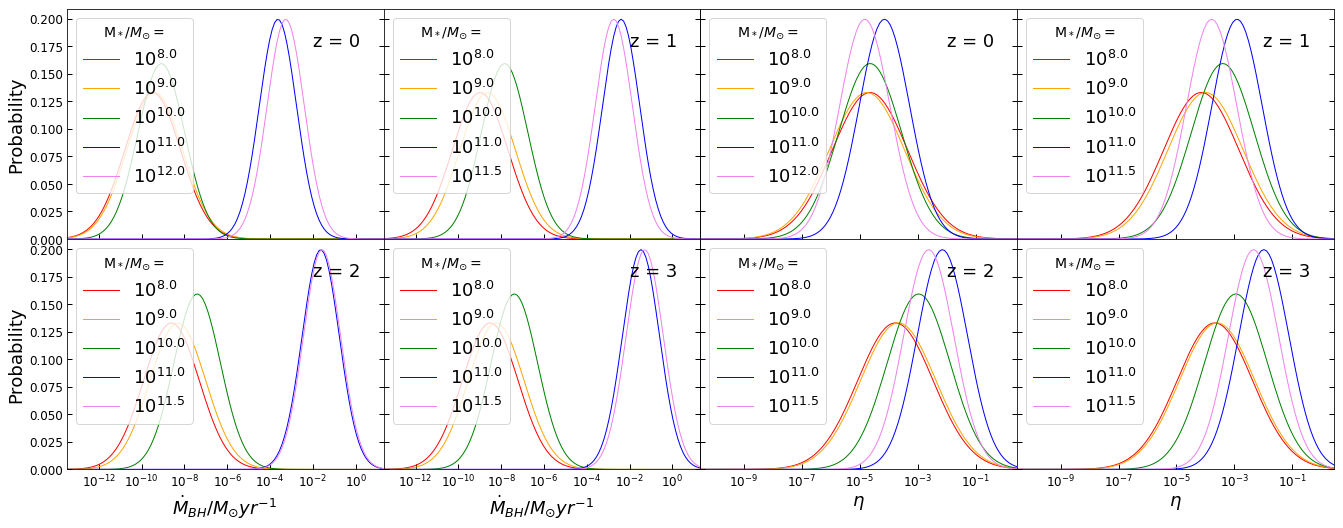

In [2]:
'''
ETA DISTRIBUTIONS
'''

twoXfour_mdot_eta(zplot = [0, 1, 2, 3], name = 'Xmodel_distributions.pdf')


 Saved figure as "plots/FINAL_paper_plots/QLF_z1_mk2.pdf"



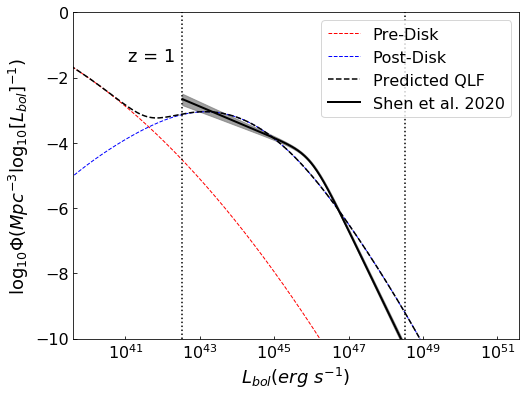

In [3]:
'''
SINGLE QLF
'''

fit_params = [0.7, 0.005, 10.25, [3.75,2.0], np.linspace(5,18,200)]

QLFwShen(z=1, fit_params=fit_params, name='QLF_z1_mk2.pdf')

In [44]:
'''
SINGLE QLF
'''
from functions_newparams import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
    qlf.SSFRs[:] = qlf.SSFRs[0]
    qlf.get_dNdlnMstar(siglnM)
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

    l1, = ax.plot(lumsp, np.log10(prea*np.log(10)), lw=1.2, c='r', linestyle='dashed', label='Pre-Disk')
    l2, = ax.plot(lumsp, np.log10(posta*np.log(10)), lw=1.2, c='b', linestyle='dashed', label='Post-Disk')
    ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10)), c='k', label = 'Predicted QLF',linestyle='dashed')
    
    
    ####### HERE IS THE SHIFTED QLF PREDICTED LINE
    #######
    ## shifting just y
#     ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10))-0.6, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    ## shifting both x and y
#     ax.plot(10**(np.log10(lumsp)+0.4), np.log10(qlf.dNdlnL * np.log(10))-0.8, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    #######
    #######
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp*np.log(10)), lw = 1.2, color = c, linestyle='dotted')#, label=f'{mass_begin}'+r'$< \log [M_*](M_\odot) <$'+f'{mass_begin+1}')
        mass_begin += 1

    ### plotting Hopkins data (if told to)
    if Hopkins == True:
        x,y,yerr = grab_obs(z)
        ax.errorbar(10**np.asarray(x)*3.8e33,y,yerr=yerr,markersize=1,fmt='o',c='gray',label='Hopkins+2006')
        
    lumsshen = np.linspace(8.95,14.95,200) ## this is tenative and an approximate range of valid observational data
    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    ### plotting Shen data and our QLF
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'orig')
#     ax.plot(xshen, dens, label='Shen Orig',c='k',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='k', alpha=.2)
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    #############
    i = np.argmin(np.abs(lumsp-10**42))
    norm = np.log10(qlf.dNdlnL[i] * np.log(10)) - dens[i]
    ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10))-norm, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)
    #############
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'b')
#     ax.plot(xshen, dens, label='Shen Global B',c='brown',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='brown', alpha=.2)
    
    ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
    ax.text(10**7.5*3.8e33,-1.5,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    ax.legend(fontsize = 8)
    
    
#     
f = h5py.File("output/chi2_3pShenfit_15_newparams-mk2.h5py", "r") 
# f = h5py.File("output/chi2_3pShenfit_15_constantSSFRtest.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits (orig, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')

###### match norm in y dir
with PdfPages('plots/match-Shen-norm.pdf') as pdf: 
    for sig in np.linspace(1.0,2.0,11):

        fig, (ax,ax2,ax3) = plt.subplots(1,3,figsize=(18,4))

        fit_params = [0.5, 0.005, 3, [1.8, sig], 0.90, 1.0, np.linspace(5,18,200)]
        ax.text(10**49, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:5])
        # fit_params = [0.2, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

        QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

        pars = 6
        cs = list(cm.Greens(np.arange(pars) / pars) ) 


        qlf = QLF(1, fit_params[1])
        qlf.SSFRs[:] = qlf.SSFRs[0]
        qlf.get_dNdlnMstar(fit_params[0])
        qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
        qlf.get_dNdlnL(fit_params[-1], fit_params[3])
        ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')

        ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
        ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
        ax2.set_xscale('log')
        ax2.set_yscale('log')
        ax2.set_xlim([10**7,10**14])
        ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
        for c, mass in zip(cs, [7,8,9,10,11,12,13]):
            ax2.axvline(10**mass, ls = 'dotted', c=c)
            ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
            ax2.legend(fontsize = 8, framealpha = 1)



        ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlnMstar), c='k')
        ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
        ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
        ax3.set_xscale('log')
        ax3.set_xlim([10**7,10**14])
        ax3.set_ylim([-7,0])
        ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
        for c, mass in zip(cs, [7,8,9,10,11,12,13]):
            ax3.axvline(10**mass, ls = 'dotted', c=c)
            ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)



        pdf.savefig(fig)
#     plt.savefig('QLF_test_constant_ssfr_loglinearMbhMstar_shift-y.pdf')




Shen best fits (orig, stacked z): minval = 7.175656980500515
Best crit = 10.36,  Best pre-disk = 1.00, Best post-disk = 2.29,  Best slope = 0.86,  Best norm = 1.50
 


FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

...

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

In [43]:
'''
SINGLE QLF
'''
from functions_newparams import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
    qlf.SSFRs[:] = qlf.SSFRs[0]
    qlf.get_dNdlnMstar(siglnM)
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

    l1, = ax.plot(lumsp, np.log10(prea*np.log(10)), lw=1.2, c='r', linestyle='dashed', label='Pre-Disk')
    l2, = ax.plot(lumsp, np.log10(posta*np.log(10)), lw=1.2, c='b', linestyle='dashed', label='Post-Disk')
    ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10)), c='k', label = 'Predicted QLF',linestyle='dashed')
    
    
    ####### HERE IS THE SHIFTED QLF PREDICTED LINE
    #######
    ## shifting just y
#     ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10))-0.6, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    ## shifting both x and y
#     ax.plot(10**(np.log10(lumsp)+0.4), np.log10(qlf.dNdlnL * np.log(10))-0.8, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    #######
    #######
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp*np.log(10)), lw = 1.2, color = c, linestyle='dotted')#, label=f'{mass_begin}'+r'$< \log [M_*](M_\odot) <$'+f'{mass_begin+1}')
        mass_begin += 1

    ### plotting Hopkins data (if told to)
    if Hopkins == True:
        x,y,yerr = grab_obs(z)
        ax.errorbar(10**np.asarray(x)*3.8e33,y,yerr=yerr,markersize=1,fmt='o',c='gray',label='Hopkins+2006')
        
    lumsshen = np.linspace(8.95,14.95,200) ## this is tenative and an approximate range of valid observational data
    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    ### plotting Shen data and our QLF
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'orig')
#     ax.plot(xshen, dens, label='Shen Orig',c='k',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='k', alpha=.2)
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    #############
    i = np.argmin(np.abs(lumsp - 1e47))
    norm = np.log10(lumsp[i]) - np.log10(xshen[i])
    ax.plot(10**(np.log10(lumsp)-norm), np.log10(qlf.dNdlnL * np.log(10)), c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)
    #############
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'b')
#     ax.plot(xshen, dens, label='Shen Global B',c='brown',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='brown', alpha=.2)
    
    ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
    ax.text(10**7.5*3.8e33,-1.5,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    ax.legend(fontsize = 8)
    
    
#     
f = h5py.File("output/chi2_3pShenfit_15_newparams-mk2.h5py", "r") 
# f = h5py.File("output/chi2_3pShenfit_15_constantSSFRtest.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits (orig, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')


##### match norm in x direction
with PdfPages('plots/match-Shen-normX.pdf') as pdf: 
    for sig in np.linspace(1.0,2.0,11):

        fig, (ax,ax2,ax3) = plt.subplots(1,3,figsize=(18,4))

        fit_params = [0.5, 0.005, 3, [1.8, sig], 0.90, 1.0, np.linspace(5,18,200)]
        ax.text(10**49, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:5])
        # fit_params = [0.2, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

        QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

        pars = 6
        cs = list(cm.Greens(np.arange(pars) / pars) ) 


        qlf = QLF(1, fit_params[1])
        qlf.SSFRs[:] = qlf.SSFRs[0]
        qlf.get_dNdlnMstar(fit_params[0])
        qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
        qlf.get_dNdlnL(fit_params[-1], fit_params[3])
        ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')

        ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
        ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
        ax2.set_xscale('log')
        ax2.set_yscale('log')
        ax2.set_xlim([10**7,10**14])
        ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
        for c, mass in zip(cs, [7,8,9,10,11,12,13]):
            ax2.axvline(10**mass, ls = 'dotted', c=c)
            ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
            ax2.legend(fontsize = 8, framealpha = 1)



        ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlnMstar), c='k')
        ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
        ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
        ax3.set_xscale('log')
        ax3.set_xlim([10**7,10**14])
        ax3.set_ylim([-7,0])
        ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
        for c, mass in zip(cs, [7,8,9,10,11,12,13]):
            ax3.axvline(10**mass, ls = 'dotted', c=c)
            ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)



        pdf.savefig(fig)
#     plt.savefig('QLF_test_constant_ssfr_loglinearMbhMstar_shift-y.pdf')




Shen best fits (orig, stacked z): minval = 7.175656980500515
Best crit = 10.36,  Best pre-disk = 1.00, Best post-disk = 2.29,  Best slope = 0.86,  Best norm = 1.50
 


FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

...

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

In [6]:
'''
SINGLE QLF
'''
from functions_SMFstart import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
#     qlf.SSFRs[:] = qlf.SSFRs[0]
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

#     l1, = ax.plot(lumsp, np.log10(prea*np.log(10)), lw=1.2, c='r', linestyle='dashed', label='Pre-Disk')
#     l2, = ax.plot(lumsp, np.log10(posta*np.log(10)), lw=1.2, c='b', linestyle='dashed', label='Post-Disk')
    ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10)), c='r', label = 'Predicted QLF',linestyle='dashed')
    
    
    ####### HERE IS THE SHIFTED QLF PREDICTED LINE
    #######
    ## shifting just y
#     ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10))-0.6, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    ## shifting both x and y
#     ax.plot(10**(np.log10(lumsp)+0.4), np.log10(qlf.dNdlnL * np.log(10))-0.8, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    #######
    #######
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp*np.log(10)), lw = 1.2, color = c, linestyle='dotted')#, label=f'{mass_begin}'+r'$< \log [M_*](M_\odot) <$'+f'{mass_begin+1}')
        mass_begin += 1

    ### plotting Hopkins data (if told to)
    if Hopkins == True:
        x,y,yerr = grab_obs(z)
        ax.errorbar(10**np.asarray(x)*3.8e33,y,yerr=yerr,markersize=1,fmt='o',c='gray',label='Hopkins+2006')
        
    lumsshen = np.linspace(8.95,14.95,200) ## this is tenative and an approximate range of valid observational data
    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    ### plotting Shen data and our QLF
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'orig')
#     ax.plot(xshen, dens, label='Shen Orig',c='k',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='k', alpha=.2)
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    #############
    i = np.argmin(lumsp-10**42)
    norm = np.log10(qlf.dNdlnL[i] * np.log(10)) - dens[i]
#     ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10))-norm, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)
    #############
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'b')
#     ax.plot(xshen, dens, label='Shen Global B',c='brown',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='brown', alpha=.2)
    
    ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
    ax.text(10**7.5*3.8e33,-1.5,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    ax.legend(fontsize = 8)
    
    
#     
f = h5py.File("output/chi2_3pShenfit_15_newparams-mk2.h5py", "r") 
# f = h5py.File("output/chi2_3pShenfit_15_constantSSFRtest.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits (orig, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')


fig, (ax,ax2,ax3) = plt.subplots(1,3,figsize=(18,4))

fit_params = [0.2, 0.005, 3, [1.8, 1.8], 0.90, 1.0, np.linspace(5,18,200)]
ax.text(10**49, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:5])
# fit_params = [0.2, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
# qlf.SSFRs[:] = qlf.SSFRs[0]
qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='r', linestyle='dashed')

ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**14])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
    ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlnMstar), c='r', linestyle='dashed')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**14])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)



plt.savefig('plots/SMFstart.pdf', transparent = True)




Shen best fits (orig, stacked z): minval = 7.175656980500515
Best crit = 10.36,  Best pre-disk = 1.00, Best post-disk = 2.29,  Best slope = 0.86,  Best norm = 1.50
 


FigureCanvasNbAgg()

In [19]:
'''
SINGLE QLF
'''
from functions_SMFstart import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
#     qlf.SSFRs[:] = qlf.SSFRs[0]
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

    l1, = ax.plot(lumsp, np.log10(prea*np.log(10)), lw=1.2, c='r', linestyle='dashed', label='Pre-Disk')
    l2, = ax.plot(lumsp, np.log10(posta*np.log(10)), lw=1.2, c='b', linestyle='dashed', label='Post-Disk')
    ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10)), c='k', label = 'Predicted QLF',linestyle='dashed')
    
    
    ####### HERE IS THE SHIFTED QLF PREDICTED LINE
    #######
    ## shifting just y
#     ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10))-0.6, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    ## shifting both x and y
#     ax.plot(10**(np.log10(lumsp)+0.4), np.log10(qlf.dNdlnL * np.log(10))-0.8, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    #######
    #######
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp*np.log(10)), lw = 1.2, color = c, linestyle='dotted')#, label=f'{mass_begin}'+r'$< \log [M_*](M_\odot) <$'+f'{mass_begin+1}')
        mass_begin += 1

    ### plotting Hopkins data (if told to)
    if Hopkins == True:
        x,y,yerr = grab_obs(z)
        ax.errorbar(10**np.asarray(x)*3.8e33,y,yerr=yerr,markersize=1,fmt='o',c='gray',label='Hopkins+2006')
        
    lumsshen = np.linspace(8.95,14.95,200) ## this is tenative and an approximate range of valid observational data
    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    ### plotting Shen data and our QLF
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'orig')
#     ax.plot(xshen, dens, label='Shen Orig',c='k',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='k', alpha=.2)
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    #############
    i = np.argmin(np.abs(xshen - 1e47))
    j = np.argmin(np.abs(np.log10(qlf.dNdlnL * np.log(10)) - dens[i]))
    norm = np.log10(xshen[i]) - np.log10(lumsp[j])
    print(i,j, norm)
    ax.plot(10**(np.log10(lumsp)+norm), np.log10(qlf.dNdlnL * np.log(10)), c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)
    #############
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'b')
#     ax.plot(xshen, dens, label='Shen Global B',c='brown',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='brown', alpha=.2)
    
    ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
    ax.text(10**7.5*3.8e33,-1.5,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    ax.legend(fontsize = 8)
    
    
#     
f = h5py.File("output/chi2_3pShenfit_15_newparams-mk2.h5py", "r") 
# f = h5py.File("output/chi2_3pShenfit_15_constantSSFRtest.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits (orig, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')


with PdfPages('plots/match-Shen-normX.pdf') as pdf: 
    for sig in np.linspace(1.5,2.5,11):

        fig, (ax,ax2,ax3) = plt.subplots(1,3,figsize=(18,4))

        fit_params = [0.2, 0.005, 3, [1.8, sig], 0.90, 1.0, np.linspace(5,18,200)]
        ax.text(10**49, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:5])
        # fit_params = [0.2, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

        QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

        pars = 6
        cs = list(cm.Greens(np.arange(pars) / pars) ) 


        qlf = QLF(1, fit_params[1])
        # qlf.SSFRs[:] = qlf.SSFRs[0]
        qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
        qlf.get_dNdlnL(fit_params[-1], fit_params[3])
        ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')

        ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
        ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
        ax2.set_xscale('log')
        ax2.set_yscale('log')
        ax2.set_xlim([10**7,10**14])
        ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
        for c, mass in zip(cs, [7,8,9,10,11,12,13]):
            ax2.axvline(10**mass, ls = 'dotted', c=c)
            ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
            ax2.legend(fontsize = 8, framealpha = 1)



        ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlnMstar), c='k')
        ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
        ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
        ax3.set_xscale('log')
        ax3.set_xlim([10**7,10**14])
        ax3.set_ylim([-7,0])
        ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
        for c, mass in zip(cs, [7,8,9,10,11,12,13]):
            ax3.axvline(10**mass, ls = 'dotted', c=c)
            ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)



        pdf.savefig(fig)



Shen best fits (orig, stacked z): minval = 7.175656980500515
Best crit = 10.36,  Best pre-disk = 1.00, Best post-disk = 2.29,  Best slope = 0.86,  Best norm = 1.50
 


FigureCanvasNbAgg()

129 119 0.653266331658287


FigureCanvasNbAgg()

129 120 0.5879396984924625


...

129 129 0.0


FigureCanvasNbAgg()

129 130 -0.06532663316583154


FigureCanvasNbAgg()

129 131 -0.13065326633166308


In [21]:
'''
SINGLE QLF
'''
from functions_newparams import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib widget


def Shen_fit_uncer(z, lums, ver): ###best fit data from Shen+2020

    def get_params(params):
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(z, [d0]) + C.chebval(1 + z, [0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_a(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)
    
    def shen_func_b(p):
        L = lums
        a0, a1, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = a0*zfrac**a1
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)

        return np.log10(Phibol)

    params = {'a0':[0.85858, 0.03092, 0.02876], 'a1':[-0.26236, 0.02003, 0.01753], 'a2':[0.02105, 0.00136, 0.00113],\
        'b0':[2.54992, 0.01915, 0.02949], 'b1':[-1.04735, 0.01815, 0.02999], 'b2':[1.13277, 0.01988, 0.03891],\
        'c0':[13.01297, 0.00943, 0.01354], 'c1':[-0.57587, 0.00205, 0.00261], 'c2':[0.45361, 0.00290, 0.00434],\
        'd0':[-3.53138, 0.02694, 0.02690], 'd1':[-0.39961, 0.00871, 0.00896]}
    
    params_a = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    
    params_b = {'a0':[0.3653, 0.0115, 0.0114], 'a1':[-0.6006, 0.0422, 0.0417],\
        'b0':[2.4709,0.0163,0.0169], 'b1':[-0.9963,0.0167,0.0161], 'b2':[1.0716, 0.0180, 0.0181],\
        'c0':[12.9656,0.0092,0.0089], 'c1':[-0.5758,0.0020,0.0019], 'c2':[0.4698,0.0025,0.0026],\
        'd0':[-3.6276,0.0209, 0.0203], 'd1':[-0.3444,0.0063,0.0061]}
    
    
    if ver == 'orig':
        param_list = np.array([params[i] for i in params])
        NUM = int(1e4)
        rand_params = get_params(params)
        ys = np.apply_along_axis(shen_func, 1, rand_params).T
        ya = shen_func(param_list[:,0])
    elif ver == 'a':
        param_list = np.array([params_a[i] for i in params_a])
        NUM = int(1e4)
        rand_params = get_params(params_a)
        ys = np.apply_along_axis(shen_func_a, 1, rand_params).T
        ya = shen_func_a(param_list[:,0]) 
    elif ver == 'b':
        param_list = np.array([params_b[i] for i in params_b])
        NUM = int(1e4)
        rand_params = get_params(params_b)
        ys = np.apply_along_axis(shen_func_b, 1, rand_params).T
        ya = shen_func_b(param_list[:,0]) 

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya

    return ya, std_ave, std_abv, std_blw





def QLFwShen_test(fit_params = None, z = 0.0, name = 'z0-QLF-v-Shen.pdf', Hopkins = False, approx_local=True):
   

    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    qlf = QLF(z, bins)
#     qlf.SSFRs[:] = qlf.SSFRs[0]
    qlf.get_dNdlnMstar(fit_params[0])
    qlf.get_Mbh(start, slope, norm, approx_local=approx_local)

    m = qlf.slopes

    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))

    for i, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        dens = i
        if pre == True:
            prea += dens
        else:
            posta += dens

#     l1, = ax.plot(lumsp, np.log10(prea*np.log(10)), lw=1.2, c='r', linestyle='dashed', label='Pre-Disk')
#     l2, = ax.plot(lumsp, np.log10(posta*np.log(10)), lw=1.2, c='b', linestyle='dashed', label='Post-Disk')
    ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10)), c='k', label = 'Predicted QLF',linestyle='solid')
    
    
    ####### HERE IS THE SHIFTED QLF PREDICTED LINE
    #######
    ## shifting just y
#     ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10))-0.6, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    ## shifting both x and y
#     ax.plot(10**(np.log10(lumsp)+0.4), np.log10(qlf.dNdlnL * np.log(10))-0.8, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)

    #######
    #######
    
    pars = 6
    mass_begin = 7
    temp = np.zeros(len(lumsp))
    cs = list(cm.Greens(np.arange(pars) / pars) ) 
    for m, n, c in zip(qlf.StellBins, range(pars), cs):
        temp = temp*0
        for dens in np.transpose(qlf.intvals)[((qlf.StellBins >= mass_begin)&(qlf.StellBins<= mass_begin+1)),:]:
            temp += dens
        l = ax.plot(lumsp, np.log10(temp*np.log(10)), lw = 1.2, color = c, linestyle='dotted')#, label=f'{mass_begin}'+r'$< \log [M_*](M_\odot) <$'+f'{mass_begin+1}')
        mass_begin += 1

    ### plotting Hopkins data (if told to)
    if Hopkins == True:
        x,y,yerr = grab_obs(z)
        ax.errorbar(10**np.asarray(x)*3.8e33,y,yerr=yerr,markersize=1,fmt='o',c='gray',label='Hopkins+2006')
        
    lumsshen = np.linspace(8.95,14.95,200) ## this is tenative and an approximate range of valid observational data
    lumsshen = lums
    xshen = 10**lumsshen*3.8e33

    ### plotting Shen data and our QLF
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'orig')
#     ax.plot(xshen, dens, label='Shen Orig',c='k',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='k', alpha=.2)
    dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'a')
    
    #############
    i = np.argmin(lumsp-10**42)
    norm = np.log10(qlf.dNdlnL[i] * np.log(10)) - dens[i]
#     ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10))-norm, c='gray', label = 'Predicted QLF (shifted)',linestyle='dotted',lw = 2.5)
    #############
    
    ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
    ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
#     dens, stanave, stanab, stanb = Shen_fit_uncer(z, lumsshen, 'b')
#     ax.plot(xshen, dens, label='Shen Global B',c='brown',lw=2,alpha = 0.5)
#     ax.fill_between(xshen, dens-stanab, dens+stanb, color='brown', alpha=.2)
    
    ax.axvline(10**8.95*3.8e33,c='k',linestyle='dotted')
    ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    ### formatting and save
    ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
    ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =12)
    ax.text(10**7.5*3.8e33,-1.5,'z = '+str(z),fontsize = 12)
    ax.set_xscale('log')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
    ax.legend(fontsize = 8)
    
    
#     
f = h5py.File("output/chi2_3pShenfit_15_newparams-mk2.h5py", "r") 
# f = h5py.File("output/chi2_3pShenfit_15_constantSSFRtest.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
chi23d = f['z=1.0/chi23d_grid'][:].T
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits (orig, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n ')


fig, (ax,ax2,ax3) = plt.subplots(1,3,figsize=(18,4))

fit_params = [0.0, 0.005, 3, [1.8, 1.8], 0.90, 1.0, np.linspace(5,18,200)]
ax.text(10**49, -4, '$\sigma_{\ln X} = $'+str(fit_params[3][1])[0:5])
# fit_params = [0.2, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm, np.linspace(5,18,200)]

QLFwShen_test(z=1, fit_params=fit_params, approx_local = True)

pars = 6
cs = list(cm.Greens(np.arange(pars) / pars) ) 


qlf = QLF(1, fit_params[1])
# qlf.SSFRs[:] = qlf.SSFRs[0]
qlf.get_dNdlnMstar(fit_params[0])

qlf.get_Mbh(fit_params[2], fit_params[4], fit_params[5], approx_local=True)
qlf.get_dNdlnL(fit_params[-1], fit_params[3])
ax2.plot(10**qlf.StellBins, qlf.SSFRs,c='k')

ax2.set_ylabel('Observed SSFR (yr$^{-1}$)',fontsize=12)
ax2.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim([10**7,10**14])
ax2.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax2.axvline(10**mass, ls = 'dotted', c=c)
    ax2.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5, label=f'{mass}'+r'$< \log [M_*](M_\odot) <$'+f'{mass+1}')
    ax2.legend(fontsize = 8, framealpha = 1)



ax3.plot(10**qlf.StellBins, np.log10(qlf.dNdlnMstar), c='k')
ax3.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [M_*]^{-1})$',fontsize=12)
ax3.set_xlabel('$M_*(M_\odot)$',fontsize=12)
ax3.set_xscale('log')
ax3.set_xlim([10**7,10**14])
ax3.set_ylim([-7,0])
ax3.tick_params(axis='both', which='both', labelsize=10, direction='in')
for c, mass in zip(cs, [7,8,9,10,11,12,13]):
    ax3.axvline(10**mass, ls = 'dotted', c=c)
    ax3.axvspan(10**mass, 10**(mass+1), color=c, alpha = 0.5)



#     plt.savefig('QLF_test_constant_ssfr_loglinearMbhMstar_shift-y.pdf')
plt.savefig('plots/HMFstart.pdf',transparent=True)



Shen best fits (orig, stacked z): minval = 7.175656980500515
Best crit = 10.36,  Best pre-disk = 1.00, Best post-disk = 2.29,  Best slope = 0.86,  Best norm = 1.50
 


FigureCanvasNbAgg()

In [10]:
'''
MULTIPLE QLF
'''
NA = '  NA'

#### Shen fits old params stacked z
f = h5py.File("output/chi2_3pShenfit_40_nw_mk3.h5py", "r")
count = 0
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
for z in [0.0,1.0,2.0,3.0,4.0]:
    if count == 0:
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
    else:
        chi23d += f['z='+str(z)+'/chi23d_grid'][:].T
    count += 1
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestpost = siglnX2[minind[0][0]]
bestpre = siglnX1[minind[1][0]]
bestcrit = logMstar0[minind[2][0]]

print('\nShen best fits (orig, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {NA},  Best norm = {NA}\n ')


# fit_params = [0.7, 0.005, 10.25, [3.75,2.0], np.linspace(5,18,200)]
fit_params = [0.7, 0.005, bestcrit, [bestpre, bestpost], np.linspace(5,18,200)]

QLF9wShen(z = [1.5, 0.0, 0.5, 1.0, 2.0, 2.5, 3.0, 3.5, 4.0], fit_params = fit_params, name = 'QLF_wShenO-params.pdf')


Shen best fits (orig, stacked z): minval = 85.91721914840592
Best crit = 10.58,  Best pre-disk = 4.46, Best post-disk = 1.23,  Best slope = NA,  Best norm = NA
 


FigureCanvasNbAgg()


 Saved figure as "plots/FINAL_paper_plots/QLF_wShenO-params.pdf"



In [2]:
'''
MULTIPLE QLF
'''
from functions_newparams import *
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
import h5py
import matplotlib.gridspec as gridspec

%matplotlib widget

def QLF9wShen(fit_params = None, z = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], name = '9-QLF-v-Shen.pdf', Hopkins = False):
    
    ### what fit params are we using
    if not fit_params:
        siglnM = 0.7
        bins = 0.005
        start = 10.0
        siglnX = [3.0, 2.0]
        lums = np.linspace(5,18,200)
    else:
        siglnM, bins, start, siglnX, slope, norm, lums = fit_params
    
    ### figure set-up
    fig = plt.figure(figsize=(30,8))
    gs = gridspec.GridSpec(2, 6)
    ax1 = fig.add_subplot(gs[0:, 0:2])
    
    ### begin plotting the main plot
    
    ### collect QLF data
    qlf = QLF(z[0], bins)
    qlf.get_dNdlnMstar(siglnM)
    qlf.get_Mbh(start, slope, norm, approx_local=True)
    qlf.get_dNdlnL(lums, siglnX)
    lumsp = 10**lums*3.8e33
    prea = np.zeros(len(lumsp))
    posta = np.zeros(len(lumsp))
    
    for dens, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
        if pre == True:
            prea += dens
        else:
            posta += dens

    ### plot main plot QLF data    
    ax1.plot(lumsp, np.log10(np.asarray(prea) * np.log(10)), c='r', label='Pre-Disk',lw=1, linestyle='dashed')
    ax1.plot(lumsp, np.log10(np.asarray(posta) * np.log(10)), c='b', label='Post-Disk',lw=1, linestyle='dashed')
    
    ax1.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10)), c='k',lw=2, label='Predicted QLF', linestyle='dashed')

    ### plot the Shen QLF
    lumsshen = np.linspace(8.95,14.95,200) ## this is tenative and an approximate range of valid observational data
    xshen = 10**lumsshen*3.8e33
    dens, stanave, stanab, stanb = Shen_fit_uncer(z[0], lumsshen)
    
    ax1.plot(xshen, dens, label='Shen et al. 2020',c='black',linestyle='solid',lw = 2)
    ax1.fill_between(xshen, dens-stanab, dens+stanb, color='gray', alpha=.75)
    ax1.axvline(xshen[0],c='k',linestyle='dotted')
    ax1.axvline(xshen[-1],c='k',linestyle='dotted')

    ### plotting Hopkins data (if told to)
    if Hopkins == True:
        x,y,yerr = grab_obs(z[0])
        ax.errorbar(10**np.asarray(x)*3.8e33,y,yerr=yerr,markersize=1,fmt='o',c='gray',label='Hopkins+2006')

    ### formatting axes
    ax1.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
    ax1.set_xlabel(r'$\log_{10} [L_{bol}] \ \ \ (erg \ s^{-1})$', fontsize=26)
    ax1.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =26)
    ax1.legend(fontsize = 20)
    ax1.text(10**7.5*3.8e33,-1.5,'z = '+str(z[0]),fontsize = 22)
    ax1.set_xscale('log')
    ax1.tick_params(axis='both', which='both', labelsize=20, direction='in')


    for r, i, j in zip(z[1:],[0,0,0,0,1,1,1,1],[2,3,4,5,2,3,4,5]):
        
        ### set up plot
        ax = fig.add_subplot(gs[i, j], sharex = ax1, sharey = ax1)
        
        ### get the QLF data
        qlf = QLF(r, bins)
        qlf.get_dNdlnMstar(siglnM)
        qlf.get_Mbh(start, slope, norm, approx_local=True)
        qlf.get_dNdlnL(lums, siglnX)
    
        prea = np.zeros(len(lumsp))
        posta = np.zeros(len(lumsp))
        latea = np.zeros(len(lumsp))
        for dens, pre, m in zip(np.transpose(qlf.intvals), qlf.pre, qlf.slopes):
            if pre == True:
                prea += dens
            else:
                posta += dens
        
        ### plot mini QLF data                    
        ax.plot(lumsp, np.log10(np.asarray(prea) * np.log(10)), c='r', label='Pre-Disk',lw=.5, linestyle='dashed')
        ax.plot(lumsp, np.log10(np.asarray(posta) * np.log(10)), c='b', label='Post-Disk',lw=.5, linestyle='dashed') 
        
        ax.plot(lumsp, np.log10(qlf.dNdlnL * np.log(10)), c='k',lw=1,linestyle='dashed')

        ### plot the Shen QLF
        dens, stanave, stanab, stanb = Shen_fit_uncer(r, lumsshen)

        ax.plot(xshen, dens, label='Shen+submitted',c='black',linestyle='solid',lw =1)
        ax.fill_between(xshen, dens-stanab, dens+stanb, color='gray', alpha=.75)
        ax.axvline(xshen[0],c='k',linestyle='dotted')
        ax.axvline(xshen[-1],c='k',linestyle='dotted')
        
                
        ### plotting Hopkins data (if told to)
        if Hopkins == True:
            x,y,yerr = grab_obs(r)
            ax.errorbar(10**np.asarray(x)*3.8e33,y,yerr=yerr,markersize=1,fmt='o',c='gray',label='Hopkins+2006')
    
        ### formatting axes
        ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
        ax.text(10**9.5*3.8e33,-1.5,'z = '+str(r),fontsize = 18)
        ax.set_xscale('log')
        ax.tick_params(axis='both', which='both', labelsize=16, direction='in')
        
    plt.tight_layout()
    plt.savefig('plots/Chi2-plots/QLF_wShenA-params.pdf')


#### Shen fits all params stacked z
count = 0
f = h5py.File("output/chi2_3pShenfit_15_newparams-mk2.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
slope_low = f['slope_low'][:]
norm_from_local = f['norm_from_local'][:]
for z in [0.0,1.0,2.0,3.0,4.0]:
    if count == 0:
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
    else:
        chi23d += f['z='+str(z)+'/chi23d_grid'][:].T
    count += 1
f.close()
minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
bestnorm = norm_from_local[minind[0][0]]
bestslope = slope_low[minind[1][0]]
bestpost = siglnX2[minind[2][0]]
bestpre = siglnX1[minind[3][0]]
bestcrit = logMstar0[minind[4][0]]

print('\nShen best fits (all, stacked z): minval =',minval)
print(f'Best crit = {bestcrit:.2f},  Best pre-disk = {bestpre:.2f}, Best post-disk = {bestpost:.2f},  Best slope = {bestslope:.2f},  Best norm = {bestnorm:.2f}\n\n ')

fit_params = [0.7, 0.005, bestcrit, [bestpre, bestpost], bestslope, bestnorm,  np.linspace(5,18,200)]

QLF9wShen(z = [1.5, 0.0, 0.5, 1.0, 2.0, 2.5, 3.0, 3.5, 4.0], fit_params = fit_params)


Shen best fits (all, stacked z): minval = 60.02125562428072
Best crit = 10.36,  Best pre-disk = 3.57, Best post-disk = 1.64,  Best slope = 0.86,  Best norm = 1.07

 


FigureCanvasNbAgg()

In [30]:
'''
FREE PARAM EFFECTS
'''

free_param_effects(z=1.5, name='free_params_effects.pdf')

FigureCanvasNbAgg()


 Saved figure as "plots/FINAL_paper_plots/free_params_effects.pdf"



-

-

-

-

Plot for postdisk Mstarcrit comparison at the most probable value of predisk

-

-

-

-

In [4]:
from matplotlib import colors

def CHI2_POSTvsCRIT(FILE = "QUEST/data/chi2_3pShenfit_nw.h5py"):
    fig = plt.figure(figsize=(22,10))
    gs = gridspec.GridSpec(3, 6)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
                     
    zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
    axi = [0,0,0,0,1,1,1,1,2,2,2,2]
    axj = [0,1,2,3,0,1,2,3,0,1,2,3]
                     
    for z, i, j in zip(zlist, axi, axj):
        
        ### retrieveing specific redshift 
        f = h5py.File(FILE, "r")
        chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
        f.close()
                     
        ### set up axis and label info
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
        file = 'post-disk_vs_logMstar0'
        cmap = 'inferno_r'
        axis = [7,12,1.5,8]
        extent = [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]]
                     
        ax = fig.add_subplot(gs[i, j])
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title('z = '+str(z))
        ax.axis(axis)
        
        preGRID = np.sum(chi23d, axis=(0,2))         #pre disk sigma value grid
        preI = np.argmin(np.abs(siglnX1-3.0))       #index value of that min value


        grid2d = chi23d[:,preI,:]
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.BoundaryNorm(boundaries=np.linspace(0,800,33), ncolors=255),vmin = 0, vmax=800, alpha=0.85)

        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,200,300,400,500],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400,500], ncolors = 220))
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400,500], ncolors = 220),linestyles='dashed')

        plt.clabel(cont, inline=True, fontsize=6, colors='k')
        stack += (grid2d) / len(zlist)

    pred = np.sum(chi23d, axis=(0,2))
    minpre =  min(np.sum(chi23d, axis=(0,2)))

    ax1 = fig.add_subplot(gs[0:2,4:])
    ax1.axis(axis)
    ax1.set_title('Stacked z')
    ax1.set_ylabel(ylabel)
    ax1.set_xlabel(xlabel)
                     
    total = ax1.imshow(stack, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.BoundaryNorm(boundaries=np.linspace(0,800,33), ncolors=255),vmin = 0, vmax=800, alpha=0.85)

    ax1.contour(stack, extent = extent, origin = 'image', linewidths=1, levels=[10], cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400,500], ncolors = 220),linestyles='dashed')
    cont = ax1.contour(stack, extent = extent, origin = 'image', linewidths=1, levels=[50,100,200,300,400,500], cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400,500], ncolors = 220))#'gist_earth')

    plt.clabel(cont, inline=True, fontsize=11, colors = 'k')

    plt.tight_layout()
    cbar = plt.colorbar(total, label=r'$\chi ^2$ ', pad = 0.05, ticks = [0,100,200,300,400,500,600,700,800])
    cbar.ax.set_yticklabels(['0', '100', '200', '300', '400', '500', '600', '700', '> 800']) 
    cbar = plt.colorbar(cont, pad = 0.05, ticks = [25,50,100,200,300,400,500])
    lines = cbar.ax.get_children()[0]
    lines.set_linewidths([50]*len(lines.get_linewidths()))
                     
    plt.text(8,0,'$\sigma_{\ln{X}}$ pre-disk = '+str(siglnX1[preI])[:6])
                     
#     plt.savefig('plots/paper-plots/chi2_ShenFit_nw'+file+'v2.0.pdf')


CHI2_POSTvsCRIT()


FigureCanvasNbAgg()

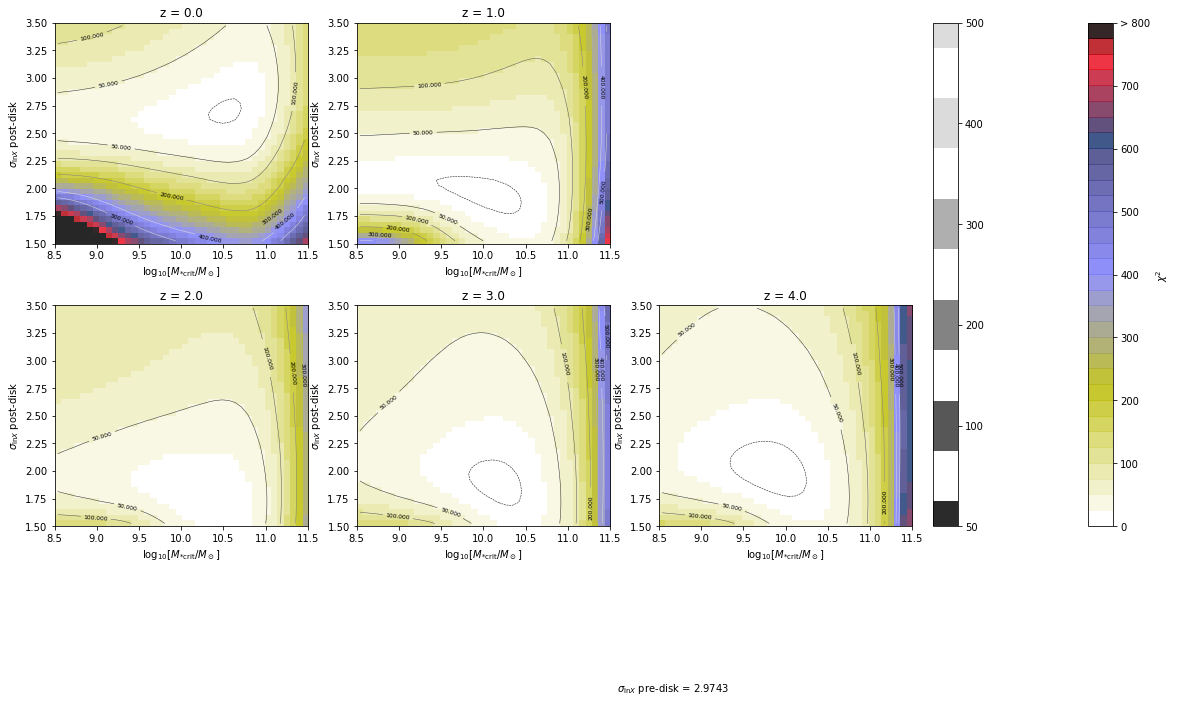

In [2]:
from matplotlib import colors

def CHI2_POSTvsCRIT(FILE = "output/chi2_3pShenfit_40_nw_mk2.h5py"):
    fig = plt.figure(figsize=(18,8))
    gs = gridspec.GridSpec(2, 3)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
                     
    zlist = [0.0, 1.0, 2.0, 3.0, 4.0]
    axi = [0,0,1,1,1]
    axj = [0,1,0,1,2]
    axes_l = []
                     
    for z, i, j in zip(zlist, axi, axj):
        
        ### retrieveing specific redshift 
        f = h5py.File(FILE, "r")
        chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
        f.close()
                     
        ### set up axis and label info
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
        file = 'post-disk_vs_MstarCRIT_40'
        axis = [8.5,11.5,1.5,3.5]
        extent = [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title('z = '+str(z))
        ax.axis(axis)
        
        preGRID = np.sum(chi23d, axis=(0,2))         #pre disk sigma value grid
        preI = np.argmin(np.abs(siglnX1-3.0))       #index value of that min value
        
        grid2d = chi23d[:,preI,:]
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.BoundaryNorm(boundaries=np.linspace(0,800,33), ncolors=255),vmin = 0, vmax=800, alpha=0.85)

        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,200,300,400,500],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400,500], ncolors = 220))
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400,500], ncolors = 220),linestyles='dashed')

        plt.clabel(cont, inline=True, fontsize=6, colors='k')
        stack += (grid2d) / len(zlist)

    pred = np.sum(chi23d, axis=(0,2))
    minpre =  min(np.sum(chi23d, axis=(0,2)))
    
    plt.tight_layout()
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.0002, ticks = [0,100,200,300,400,500,600,700,800], ax = axes_l)
    cbar.ax.set_yticklabels(['0', '100', '200', '300', '400', '500', '600', '700', '> 800']) 
    cbar = plt.colorbar(cont, pad = 0.02, ticks = [25,50,100,200,300,400,500],  ax = axes_l)
    lines = cbar.ax.get_children()[0]
    lines.set_linewidths([50]*len(lines.get_linewidths()))
                     
    plt.text(8,0,'$\sigma_{\ln{X}}$ pre-disk = '+str(siglnX1[preI])[:6])
    
#     plt.savefig('plots/paper-plots/chi2_Shen_nw'+file+'.pdf')


CHI2_POSTvsCRIT()


In [59]:
from matplotlib import colors

def CHI2_POSTvsCRIT(FILE = "output/chi2_3pShenfit_40_nw_mk2.h5py"):
    fig = plt.figure(figsize=(15,9))
    gs = gridspec.GridSpec(3, 3)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
                     
    zlist = [0.0,1.0,1.5,2.0,2.5,3.0,4.0,5.0,6.0]
    axi = [0,0,0,1,1,1,2,2,2]
    axj = [0,1,2,0,1,2,0,1,2]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)

    for z, i, j in zip(zlist, axi, axj):
        
        ### retrieveing specific redshift 
        f = h5py.File(FILE, "r")
        chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
        f.close()
                     
        ### set up axis and label info
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$'
        file = 'post-disk_vs_MstarCRIT_40'
        axis = [8.5,11.5,1.5,3.5]
        extent = [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.axis(axis)
        ax.tick_params(axis='both', direction='in')
        plt.setp(ax, xticks=np.linspace(8.75,11.25,6),
        yticks=[1.75,2.25,2.75,3.25])
        
        preGRID = np.sum(chi23d, axis=(0,2))         #pre disk sigma value grid
        preI = np.where((preGRID == min(preGRID)))[0][0]  #index value of that min value
        
        grid2d = chi23d[:,preI,:]
        
        norm = colors.LogNorm()
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm=norm, vmin = 1, vmax=400, alpha=0.85)
        cont = ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[50,100,200,300],cmap='binary_r', vmin = 10, vmax = 400, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220))
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
        ax.contour(grid2d, extent = extent, origin = 'image',linewidths=.5,levels=[10],cmap='binary_r', vmin = 10, vmax = 500, norm=matplotlib.colors.BoundaryNorm(boundaries=[10,50,100,200,300,400], ncolors = 220),linestyles='dashed')
        ax.text(9.75,3.25,'z = '+str(z), bbox=props, fontsize=12)

    
    plt.suptitle('Shen et al. (2020) Fits',fontsize=15)        
    plt.subplots_adjust(wspace=0, hspace=0)
    
    plt.setp(axes_l[0].get_xticklabels(), visible=False)  
    plt.setp(axes_l[1].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_xticklabels(), visible=False) 
    plt.setp(axes_l[3].get_xticklabels(), visible=False)    
    plt.setp(axes_l[4].get_xticklabels(), visible=False)    
    plt.setp(axes_l[5].get_xticklabels(), visible=False) 
    
    axes_l[6].set_xlabel(xlabel,fontsize=12)
    axes_l[7].set_xlabel(xlabel,fontsize=12)
    axes_l[8].set_xlabel(xlabel,fontsize=12)
    axes_l[0].set_ylabel(ylabel,fontsize=12)
    axes_l[3].set_ylabel(ylabel,fontsize=12)
    axes_l[6].set_ylabel(ylabel,fontsize=12)
    
    plt.setp(axes_l[1].get_yticklabels(), visible=False)
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    plt.setp(axes_l[4].get_yticklabels(), visible=False)
    plt.setp(axes_l[5].get_yticklabels(), visible=False)
    plt.setp(axes_l[7].get_yticklabels(), visible=False)
    plt.setp(axes_l[8].get_yticklabels(), visible=False) 
    
    
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l, ticks = [1, 2, 3, 4, 6, 8, 10, 20, 30, 40, 60, 80, 100, 200, 300, 400], format="%d").set_label(label=r'$\chi ^2$ ',size=12)
                         
    plt.savefig('plots/FINAL_paper_plots/CHI2_SHEN.pdf')


CHI2_POSTvsCRIT()


FigureCanvasNbAgg()

Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x1140e7730> (for post_execute):


AttributeError: 'FigureCanvasNbAgg' object has no attribute 'manager'

516.3333317175479 (array([4]), array([24]), array([28]))
1.705128205128205 4.365384615384615 10.301282051282051


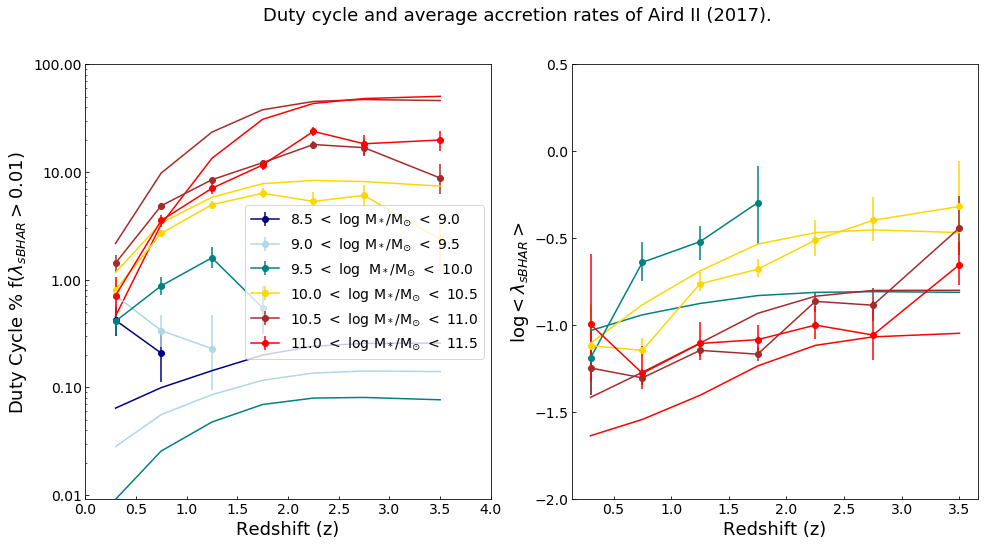

In [13]:
####### USING THEIR DEFINITION EXACTLY ##########
from functions_notfuckedup import *
from matplotlib.ticker import FormatStrFormatter
# from matplotlib import rc
# rc('font',**{'family':'serif','serif':['Times']})
# rc('text', usetex=True)


f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
chi23d = f['chi23d_grid'][:].T
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
f.close()

minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
print(minval, minind)

bestpost = siglnX2[minind[0][0]]
bestpre = siglnX1[minind[1][0]]
bestcrit = logMstar0[minind[2][0]]

print(bestpost, bestpre, bestcrit)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,8))
fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']


duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
        per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

yerr = np.zeros([2,len(el)])
yerr[0,:], yerr[1,:] = el, eh

mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))

# pre, post, SIG_lnMs, Ms_crit, b = 3.75, 2.0, 0.7, 10.25, 0.005
pre, post, SIG_lnMs, Ms_crit, b = bestpre, bestpost, 0.7, bestcrit, 0.005


L = np.linspace(5,18,200) #log10 of solar luminosities

count = 0

DUTY_tot = np.zeros((len(mass),len(ztot)))
aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

def dut_eta(Ms, ind):
    MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
    lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

    y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
    duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
    aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])
    
    return duty, aveeta

zcount = 0
for z in ztot:
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(Ms_crit, approx_local=True)
    qlf.get_dNdlnL(L, [pre, post])
    
    MdotBH = np.e**qlf.Mdot_mu_sig[:,3]
    MU_MdotBH = qlf.Mdot_mu_sig[:,0]
    SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
    lnMs = qlf.StellBins
    dNdlnMstar = qlf.dNdlnMstar
    
    lnLbol = np.log(10**L*3.83e33) #log of erg/s
    MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s
    
    Mcount = 0
    for Ms in mass:
        inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
        lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
        h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
        for i in inds:
            dut, eta = dut_eta(lnMs[i], i)
            DUTY_tot[Mcount,zcount] += dut*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] += eta*h
        if Mcount >= 2:
            aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
        DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
        Mcount += 1
    zcount += 1
    
pcount = 0
for i, c in zip(range(0,len(mass)), colors):
    ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
    if pcount >= 2:
        ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
    pcount+=1
    

for i, c, l in zip(mass, colors, labels):
    ind = np.where(np.array(ml) == i)[0]
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = np.array(yerr)[:,ind]
    
    ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)
    
    
for c in ['teal', 'gold', 'brown', 'r']:
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for i in duty_arid.readlines():
        s = i.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    yerr = np.zeros([2,len(yerrup)])
    yerr[0,:] = yerrdown
    yerr[1,:] = yerrup
    duty_arid.close()

    ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c)  
    
    

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.legend(fontsize = 14)

ax1.set_yscale('log')
ax1.set_xlim([0, 4])
ax1.set_ylim([0, 100])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    
ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.set_ylim([-2,0.5])

fig.savefig('plots/FINAL_paper_plots/ARID.pdf')


No handles with labels found to put in legend.


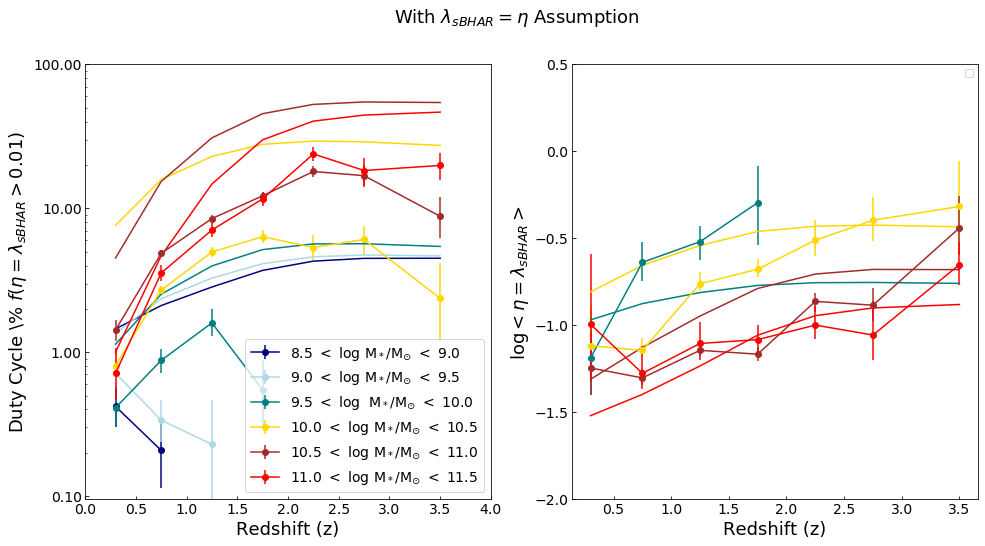

In [6]:
####### USING THE ASSUMPTION ##########
# from functions import *
# # from matplotlib import rc
# # rc('font',**{'family':'serif','serif':['Times']})
# # rc('text', usetex=True)

# fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,8))
# fig.suptitle('With $\lambda_{sBHAR} = \eta$ Assumption',fontsize=18)
# colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
# labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
#           r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']


# duty_arid = open("plot_data/fduty_vs_z.dat",'r')
# all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

# for i in duty_arid.readlines():
#     s = i.split()
#     if s[0] == 'All':
#         zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
#         per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

# yerr = np.zeros([2,len(el)])
# yerr[0,:], yerr[1,:] = el, eh

# mass = [8.5,9.0,9.5,10.0,10.5,11.0]
# ztot = sorted(set((np.array(zl) + np.array(zh))/2))

# pre, post, SIG_lnMs, Ms_crit, b = 3.75, 2.0, 0.7, 10.25, 0.005


# L = np.linspace(5,18,200) #log10 of solar luminosities


# count = 0

# DUTY_tot = np.zeros((len(mass),len(ztot)))
# aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

# criteria = np.log(0.01)

# def dut_eta(Ms, ind): #log dimensionless
#     y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lneta - MU_lneta[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
#     duty = np.trapz(y[lneta>=criteria]*dNdlnMstar[ind], x=lneta[lneta>=criteria])
#     aveeta = np.sum(y[lneta>=criteria]*np.e**lneta[lneta>=criteria]*(lneta[1]-lneta[0])*dNdlnMstar[ind])
    
#     return duty, aveeta

# zcount = 0
# for z in ztot:
#     qlf = QLF(z, b)
#     qlf.get_dNdlnMstar(SIG_lnMs)
#     qlf.get_Mbh(Ms_crit, approx_local=True)
#     qlf.get_dNdlnL(L, [pre, post])
    
#     MdotBH = qlf.MdotBH
#     MU_MdotBH = qlf.Mdot_mu_sig[:,0]
#     SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
#     lnMs = qlf.StellBins
#     dNdlnMstar = qlf.dNdlnMstar
#     MU_lneta = MU_MdotBH - np.log(qlf.Mdotedd)
#     lneta = np.linspace(-25, 2, 200)

# #     lnLbol = np.log(10**L*3.83e33) #log of erg/s
# #     MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

#     Mcount = 0
#     for Ms in mass:
#         inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
#         lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
#         h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
#         for i in inds:
#             dut, eta = dut_eta(lnMs[i], i)
#             DUTY_tot[Mcount,zcount] += dut*h
#             if Mcount >= 2:
#                 aveETA_tot[Mcount-2,zcount] += eta*h
#         if Mcount >= 2:
#             aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
#         DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
#         Mcount += 1
#     zcount += 1
    
# pcount = 0
# for i, c in zip(range(0,len(mass)), colors):
#     ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
#     if pcount >= 2:
#         ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
#     pcount+=1
    

# for i, c, l in zip(mass, colors, labels):
#     ind = np.where(np.array(ml) == i)[0]
#     z = (np.array(zl)[ind]+np.array(zh)[ind])/2
#     dut = np.array(per)[ind]
#     err = np.array(yerr)[:,ind]
    
#     ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)
    
    
# for c in ['teal', 'gold', 'brown', 'r']:
#     x = []
#     y = []
#     yerrup = []
#     yerrdown = []
#     duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
#     for i in duty_arid.readlines():
#         s = i.split()
#         if s[0][0] != '#' and s[0] == c:
#             x.append(float(s[1]))
#             y.append(float(s[2]))
#             yerrup.append(float(s[3])-float(s[2]))
#             yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
#     yerr = np.zeros([2,len(yerrup)])
#     yerr[0,:] = yerrdown
#     yerr[1,:] = yerrup
#     duty_arid.close()

#     ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 

# ax1.set_xlabel('Redshift (z)',fontsize=18)
# ax1.set_ylabel('Duty Cycle \% $f(\eta = \lambda_{sBHAR} > 0.01)$',fontsize=18)
# ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
# ax1.legend(fontsize = 14)
# ax1.set_yscale('log')
# ax1.set_xlim([0, 4])
# ax1.set_ylim([0, 100])
# ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))



# ax2.set_xlabel('Redshift (z)',fontsize=18)
# ax2.set_ylabel('$\log<\eta = \lambda_{sBHAR}>$',fontsize=18)
# ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
# ax2.set_ylim([-2,0.5])


# fig.savefig('plots/FINAL_paper_plots/ARID_Yassumption.pdf')


In [36]:
####### USING THEIR DEFINITION EXACTLY ##########
from functions import *



#### this collects the arid duty data
duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []
### read through file
for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
        per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
### collect the error values
yerr = np.zeros([2,len(el)])
yerr[0,:], yerr[1,:] = el, eh

### set up mass bins and list of z values to evaluate
mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))

### set up duty arid data to compare
DUTY_ARID = np.zeros((len(mass),len(ztot)))
DUTY_ARID_errup = np.zeros((len(mass),len(ztot)))
DUTY_ARID_errdown = np.zeros((len(mass),len(ztot)))

aveETA_ARID = np.zeros((len(mass)-2, len(ztot)))
aveETA_ARID_errup = np.zeros((len(mass)-2, len(ztot)))
aveETA_ARID_errdown =  np.zeros((len(mass)-2, len(ztot)))
###
### collect duty for compare
for m, i in zip(mass, range(len(mass))):
    ind = np.where(np.array(ml) == m)[0]
    DUTY_ARID[i,0:len(ind)] = np.array(per)[ind]
    DUTY_ARID_errup[i,0:len(ind)] = yerr[1,ind]
    DUTY_ARID_errdown[i,0:len(ind)] = yerr[0,ind]
###
### collect ave eta for compare
colors = ['teal', 'gold', 'brown', 'r']
for i, c in zip(range(len(mass)-2), colors):
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for line in duty_arid.readlines():
        s = line.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    aveETA_ARID[i,0:len(x)] = np.array(y)
    aveETA_ARID_errup[i,0:len(x)] = np.array(yerrup)
    aveETA_ARID_errdown[i,0:len(x)] = np.array(yerrdown)
    duty_arid.close()  
    
dutyinds = np.where((DUTY_ARID != 0))
etainds = np.where((aveETA_ARID != 0))



#### now i do calculations based on our function
pre, post, SIG_lnMs, Ms_crit, b = 4, 3.25, 0.7, 10, 0.005
L = np.linspace(5,18,200) #log10 of solar luminosities
#### initialize
count = 0
DUTY_tot = np.zeros((len(mass),len(ztot)))
aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

#### function to calculate the values based on a mstar value and the index of that specific values for related values
def dut_eta(Ms, ind):
    MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
    lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

    y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
    duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
    aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])
    
    return duty, aveeta

#### loop through z values first because it saves time
zcount = 0
for z in ztot:
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(Ms_crit, approx_local=True)
    qlf.get_dNdlnL(L, [pre, post])
    
    MdotBH = qlf.MdotBH
    MU_MdotBH = qlf.Mdot_mu_sig[:,0]
    SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
    lnMs = qlf.StellBins
    dNdlnMstar = qlf.dNdlnMstar
    
    lnLbol = np.log(10**L*3.83e33) #log of erg/s
    MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s
    
    Mcount = 0
    for Ms in mass:
        inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
        lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
        h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
        for i in inds:
            dut, eta = dut_eta(lnMs[i], i)
            DUTY_tot[Mcount,zcount] += dut*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] += eta*h
        if Mcount >= 2:
            aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
        DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
        Mcount += 1
    zcount += 1

DUTY_tot = np.log10(DUTY_tot*100)
aveETA_tot = np.log10(aveETA_tot)
DUTY_ARID = np.log10(DUTY_ARID)
DUTY_ARID_errup = np.log10(DUTY_ARID_errup)
DUTY_ARID_errdown = np.log10(DUTY_ARID_errdown)


def get_chi2(ym, ya, err_abv, err_blw):
    abv = (ym[ym > ya] - ya[ym > ya])**2 / err_abv[ym > ya]**2
    blw = (ym[ym < ya] - ya[ym < ya])**2 / err_blw[ym < ya]**2
    abv[np.where((abv>100.))] = 100.
    blw[np.where((blw>100.))] = 100.
    print(abv,blw)
    return np.sum(abv) + np.sum(blw)

chi2 = 0
ym, ya = DUTY_tot[dutyinds], DUTY_ARID[dutyinds]
err_abv, err_blw = DUTY_ARID_errup[dutyinds], DUTY_ARID_errdown[dutyinds]
chi2 += get_chi2(ym, ya, err_abv, err_blw)
ym, ya = aveETA_tot[etainds], aveETA_ARID[etainds]
err_abv, err_blw = aveETA_ARID_errup[etainds], aveETA_ARID_errdown[etainds]
chi2 += get_chi2(ym, ya, err_abv, err_blw)

print(chi2)

### DUTY_tot is my duty values first index is mass bin second index is redshift
### aveETA_tot is my eta values first index is mass bin second index is redshift
### similar for ARID values and their errors



[ 0.32102143  0.18475996  0.47793188  3.84145303 32.24836388  4.79585202
  8.24310148  0.22886447] [5.46318984e-01 2.96194761e-02 2.51808158e+00 4.21577017e-01
 1.10316691e-01 2.53433917e+00 3.09314944e+00 7.16254497e+00
 1.42755388e+00 5.77850037e-03 3.97466327e-02 1.77626869e-02
 1.32363015e-02 2.28753315e-01 9.36338822e-03 4.71606179e-02
 9.92732360e-01 5.27596449e+00 4.41685632e+00 8.68150023e-01
 1.15673398e-01 1.21644937e-01]
[  2.16061629  77.38459323  40.78853671  69.08318028  10.31780991
   3.69338588   0.40779957   1.38956524 100.         100.
 100.         100.          32.48790114   0.47679611   4.05837111
   7.38949406  35.11304479  22.53638629  10.33327858   3.18089162] [2.71817496e-03 2.09461984e+01 2.66132980e+01 9.06637839e+00
 1.41699093e-01]
857.9096151669644


In [1]:
from functions import *
pre, post, lnM, Mcrit, b = 3, 2, 0.7, 9.5, 0.005
lums = np.linspace(5,18,200)

qlf = QLF(1.5, b)
qlf.get_dNdlnMstar(lnM)
qlf.get_Mbh(Mcrit, approx_local=True)
for i in range(3):
    %timeit qlf.get_dNdlnL(lums, [pre, post])
%prun qlf.get_dNdlnL(lums, [pre, post])

# from functions_notfuckedup import *

# qlf = QLF(1.5, b)
# qlf.get_dNdlnMstar(lnM)
# qlf.get_Mbh(Mcrit, approx_local=True)
# for i in range(3):
#     %timeit qlf.get_dNdlnL(lums, [pre, post])
# # %prun qlf.get_dNdlnL(lums, [pre, post])

13.5 ms ± 144 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
17.4 ms ± 2.63 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
17.7 ms ± 2.26 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
 

         6351 function calls (6349 primitive calls) in 0.017 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      200    0.007    0.000    0.007    0.000 functions.py:261(gauss_Mdot)
        2    0.003    0.001    0.016    0.008 shape_base.py:270(apply_along_axis)
      839    0.002    0.000    0.002    0.000 functions.py:250(get_Mdotbh)
     1049    0.002    0.000    0.002    0.000 {built-in method numpy.array}
        1    0.001    0.001    0.017    0.017 functions.py:271(get_dNdlnL)
     1041    0.001    0.000    0.001    0.000 shape_base.py:373(<genexpr>)
     1041    0.001    0.000    0.001    0.000 index_tricks.py:653(__next__)
     1043    0.000    0.000    0.002    0.000 numeric.py:541(asanyarray)
1043/1041    0.000    0.000    0.000    0.000 {built-in method builtins.next}
        7    0.000    0.000    0.000    0.000 {built-in method numpy.zeros}
        2    0.000    0.000    0.000    0.000 {method 'reduce' of '

In [37]:
from matplotlib import colors
%matplotlib widget
plt.close('all')

def CHI2_POSTvsCRIT(FILE = "output/chi2_3pARIDfit_15_yw_mk2.h5py"):
    fig = plt.figure(figsize=(8,8))
    gs = gridspec.GridSpec(3, 1)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                     
    zlist = [0.0, 1.0, 2.0, 3.0, 4.0]
    axj = [0,0,0]
    axi = [0,1,2]
    axes_l = []
    
    extents = [[logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]]
        
    xlabels = [r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\sigma_{\ln{X}}$ post-disk', r'$\sigma_{\ln{X}}$ post-disk']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[7.25,11.5,1.75,6.0],[7.25,11.5,1.5,3.5],[1.75,6.0,1.5,3.5]]
    vmin = [400, 500, 500]
    vmax = [2000, 2000, 2000]
    gammas = [0.25, 0.4, 0.4]
                     
    for ind, i, j in zip(range(3), axi, axj):
        f = h5py.File(FILE, "r")
        chi23d = f['chi23d_grid'][:].T
        f.close()

        
        minval = min(np.sum(chi23d, axis=axiss[ind]))
        minIND = np.where((np.sum(chi23d, axis=axiss[ind]) == minval))[0][0]
                     
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        file = 'DUTY_aveSBHAR_15'
        axis = axess[ind]
        extent = extents[ind]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel)
        
        ax.set_ylabel(ylabel)
        ax.axis(axis)

        
        if sums[ind] == 1:
            grid2d = chi23d[:,minIND,:]
        elif sums[ind] == 2:
            grid2d = chi23d[:,:,minIND]
        elif sums[ind] == 0:
            grid2d = chi23d[minIND,:,:]
            
        norm = colors.LogNorm()
        norm=colors.PowerNorm(gamma=gammas[ind])
        img = ax.imshow(grid2d, cmap = 'cool', interpolation = 'nearest', aspect='auto', extent = extent, norm = norm)#, vmin = vmin[ind], vmax = vmax[ind])
        cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.0002, ax = ax, ticks = [600,800,1000,1500,2500,3500])
        cont = ax.contour(grid2d, extent = extent, cmap='Greys_r', origin = 'image',linewidths=.5, levels = [600,800,1000,1200,1400])
        cbar = plt.colorbar(cont, pad = 0.02,  ax = ax)
        lines = cbar.ax.get_children()[0]
        lines.set_linewidths([35]*len(lines.get_linewidths()))
        
        plt.clabel(cont, inline=True, fontsize=6, colors='k')
    
    plt.tight_layout()
                         
    plt.savefig('plots/paper-plots/chi2_'+file+'.pdf')


CHI2_POSTvsCRIT()


FigureCanvasNbAgg()

516.3333317175479 (array([4]), array([24]), array([28]))
1.705128205128205 4.365384615384615 10.301282051282051
516.3333317175479 (array([4]), array([24]), array([28]))
1.705128205128205 4.365384615384615 10.301282051282051
516.3333317175479 (array([4]), array([24]), array([28]))
1.705128205128205 4.365384615384615 10.301282051282051


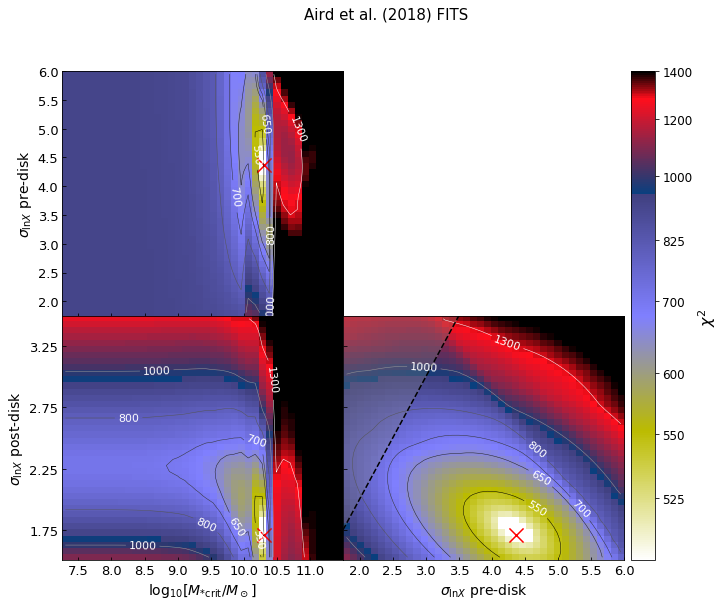

In [2]:
###### GLOBAL MIN PLOT
from matplotlib import colors


def CHI2_POSTvsCRIT(FILE = "output/chi2_3pARIDfit_40_yw_mk2.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                   
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    
    extents = [[logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]]
        
    xlabels = ['', r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\sigma_{\ln{X}}$ post-disk', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[7.25,11.5,1.75,6.0],[7.25,11.5,1.5,3.5],[1.75,6.0,1.5,3.5]]
    xticks = [[7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], [7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], np.linspace(2,6,9)]
    yticks = [np.linspace(2,6,9),[1.75,2.25,2.75,3.25],[1.75,2.25,2.75,3.25]]

                     
    for ind, i, j in zip(range(3), axi, axj):
        f = h5py.File(FILE, "r")
        chi23d = f['chi23d_grid'][:].T
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        print(minval, minind)
        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        print(bestpost, bestpre, bestcrit)
        
#         minval = min(np.sum(chi23d, axis=axiss[ind]))
#         minIND = np.where((np.sum(chi23d, axis=axiss[ind]) == minval))[0][0]
                     
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        file = 'DUTY_aveSBHAR_40'
        axis = axess[ind]
        extent = extents[ind]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=14)
        ax.set_ylabel(ylabel,fontsize=14)
        ax.axis(axis)
        ax.tick_params(axis='both', which='both', labelsize=13, direction='in')

        
        plt.setp(ax, xticks=xticks[ind],
        yticks=yticks[ind])
        
        if sums[ind] == 1:
#             grid2d = chi23d[:,minIND,:]
            grid2d = chi23d[:,minind[1][0],:]
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
#             grid2d = chi23d[:,:,minIND]
            grid2d = chi23d[:,:,minind[2][0]]
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 0:
#             grid2d = chi23d[minIND,:,:]
            grid2d = chi23d[minind[0][0],:,:]

            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
            
        norm = colors.LogNorm()
        norm=colors.PowerNorm(gamma=0.4)
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm = norm, vmin = 520, vmax = 1400)

        cont = ax.contour(grid2d, extent = extent, cmap='binary_r', origin = 'image',linewidths=.5, levels = [550,650,700,800,1000,1300])
        plt.clabel(cont, inline=True, fontsize=11, colors='w', fmt = '%d')
       
    plt.suptitle('Aird et al. (2018) FITS', fontsize = 15)
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l, ticks = [525,550,600,700,825,1000,1200,1400])
    cbar.set_label(label=r'$\chi ^2$ ',size=16)
    cbar.ax.tick_params(labelsize=12)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False) 

    axes_l[2].plot(np.linspace(1.75,6,5),np.linspace(1.75,6,5), linestyle = 'dashed',c='k')
    axes_l[2].fill_between(np.linspace(1.75,6,5), np.linspace(1.75,6,5), np.linspace(1.75,6,5)+20, color='gray', alpha=.3)
    plt.savefig('plots/FINAL_paper_plots/CHI2_AIRD.pdf')

    

CHI2_POSTvsCRIT()


0.0
2.15062142773055
[[ -192.00326648  -192.00326648  -192.00326648 ... -1000.
  -1000.         -1000.        ]
 [ -192.00326648  -192.00326648  -192.00326648 ... -1000.
  -1000.         -1000.        ]
 [ -192.00326648  -192.00326648  -192.00326648 ... -1000.
  -1000.         -1000.        ]
 ...
 [ -192.00326648  -192.00326648  -192.00326648 ... -1000.
  -1000.         -1000.        ]
 [ -192.00326648  -192.00326648  -192.00326648 ... -1000.
  -1000.         -1000.        ]
 [ -192.00326648  -192.00326648  -192.00326648 ... -1000.
  -1000.         -1000.        ]]
1.898219557939956
[[ -571.82798783  -571.82798783  -571.82798783 ... -1000.
  -1000.         -1000.        ]
 [ -524.3974355   -524.3974355   -524.3974355  ... -1000.
  -1000.         -1000.        ]
 [ -479.52705143  -479.52705143  -479.52705143 ... -1000.
  -1000.         -1000.        ]
 ...
 [ -655.4973994   -655.4973994   -655.4973994  ... -1000.
  -1000.         -1000.        ]
 [ -689.83188043  -689.83188043  -689.83

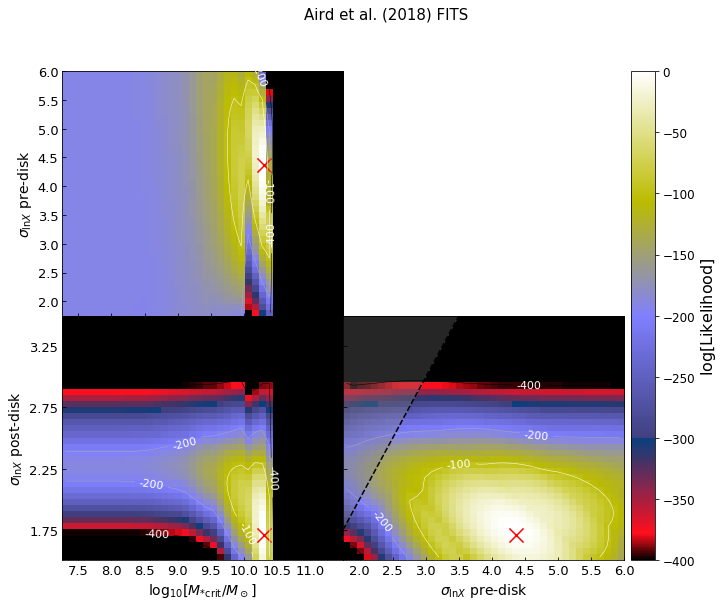

In [7]:
###### LIKELIHOOD SUM PLOT
from matplotlib import colors


def CHI2_POSTvsCRIT(FILE = "output/chi2_3pARIDfit_40_yw_mk2.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                   
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    
    extents = [[logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]]
        
    xlabels = ['', r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\sigma_{\ln{X}}$ post-disk', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[7.25,11.5,1.75,6.0],[7.25,11.5,1.5,3.5],[1.75,6.0,1.5,3.5]]
    xticks = [[7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], [7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], np.linspace(2,6,9)]
    yticks = [np.linspace(2,6,9),[1.75,2.25,2.75,3.25],[1.75,2.25,2.75,3.25]]

                     
    for ind, i, j in zip(range(3), axi, axj):
        f = h5py.File(FILE, "r")
        chi23d = f['chi23d_grid'][:].T
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)

        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        
#         minval = min(np.sum(chi23d, axis=axiss[ind]))
#         minIND = np.where((np.sum(chi23d, axis=axiss[ind]) == minval))[0][0]
                     
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        file = 'DUTY_aveSBHAR_40'
        axis = axess[ind]
        extent = extents[ind]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=14)
        ax.set_ylabel(ylabel,fontsize=14)
        ax.axis(axis)
        ax.tick_params(axis='both', which='both', labelsize=13, direction='in')

        
        plt.setp(ax, xticks=xticks[ind],
        yticks=yticks[ind])
        
        if sums[ind] == 1:
#             grid2d = chi23d[:,minIND,:]
            grid2d = np.sum(np.e**(-chi23d+minval), axis = 1)
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
#             grid2d = chi23d[:,:,minIND]
            grid2d = np.sum(np.e**(-chi23d+minval), axis = 2)
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 0:
#             grid2d = chi23d[minIND,:,:]
            grid2d = np.sum(np.e**(-chi23d+minval), axis = 0)
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
    
        print(np.amax(grid2d))
        grid2d = np.log(grid2d)
        grid2d[(grid2d == -np.inf)] = -1000
        print(grid2d)
#         norm = colors.LogNorm()
#         norm=colors.PowerNorm(gamma=0.4)
        img = ax.imshow(grid2d, cmap = 'gist_stern', interpolation = 'nearest', aspect='auto', extent = extent, vmin = -400, vmax = 0)#, norm = norm)#, vmin = 10e-300, vmax = 10e-224)

        cont = ax.contour(grid2d, extent = extent, cmap='binary_r', origin = 'image',linewidths=.5, levels = [-400,-200,-100])
        plt.clabel(cont, inline=True, fontsize=11, colors='w', fmt = '%d')
       
    plt.suptitle('Aird et al. (2018) FITS', fontsize = 15)
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l)#, ticks = [525,550,600,700,825,1000,1200,1400])
    cbar.set_label(label=r'$\log$[Likelihood]',size=16)
    cbar.ax.tick_params(labelsize=12)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False) 

    axes_l[2].plot(np.linspace(1.75,6,5),np.linspace(1.75,6,5), linestyle = 'dashed',c='k')
    axes_l[2].fill_between(np.linspace(1.75,6,5), np.linspace(1.75,6,5), np.linspace(1.75,6,5)+20, color='gray', alpha=.3)
    plt.savefig('plots/paper-plots/CHI2_AIRD_likelihood-sum.pdf')

    
print(np.e**-1000)
CHI2_POSTvsCRIT()


516.3333317175479 (array([4]), array([24]), array([28]))
1.705128205128205 4.365384615384615 10.301282051282051
516.3333317175479 (array([4]), array([24]), array([28]))
1.705128205128205 4.365384615384615 10.301282051282051
516.3333317175479 (array([4]), array([24]), array([28]))
1.705128205128205 4.365384615384615 10.301282051282051


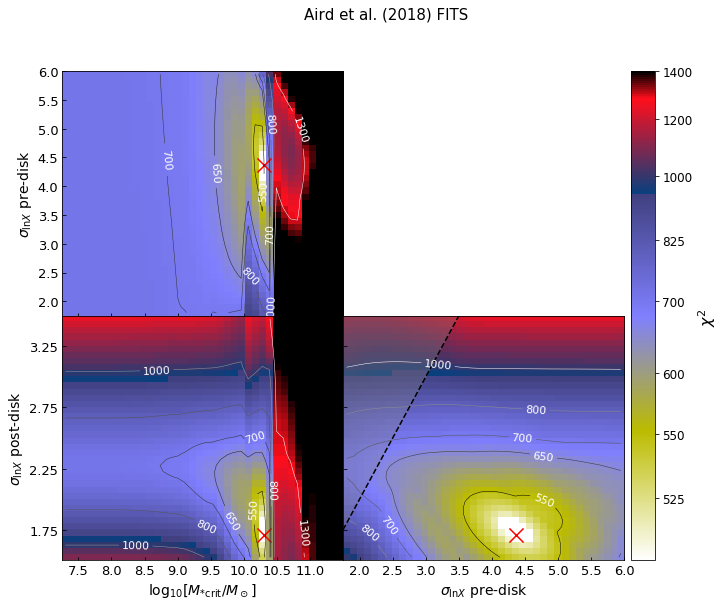

In [17]:
###### INDIVIDUAL PIXEL MAX 
from matplotlib import colors


def CHI2_POSTvsCRIT(FILE = "output/chi2_3pARIDfit_40_yw_mk2.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                   
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    
    extents = [[logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]]
        
    xlabels = ['', r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\sigma_{\ln{X}}$ post-disk', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[7.25,11.5,1.75,6.0],[7.25,11.5,1.5,3.5],[1.75,6.0,1.5,3.5]]
    xticks = [[7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], [7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], np.linspace(2,6,9)]
    yticks = [np.linspace(2,6,9),[1.75,2.25,2.75,3.25],[1.75,2.25,2.75,3.25]]

                     
    for ind, i, j in zip(range(3), axi, axj):
        f = h5py.File(FILE, "r")
        chi23d = f['chi23d_grid'][:].T
        f.close()
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)
        print(minval, minind)
        
        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
        
        print(bestpost, bestpre, bestcrit)
        
        minval = min(np.sum(chi23d, axis=axiss[ind]))
        minIND = np.where((np.sum(chi23d, axis=axiss[ind]) == minval))[0][0]
                     
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        file = 'DUTY_aveSBHAR_40'
        axis = axess[ind]
        extent = extents[ind]
                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=14)
        ax.set_ylabel(ylabel,fontsize=14)
        ax.axis(axis)
        ax.tick_params(axis='both', which='both', labelsize=13, direction='in')

        
        plt.setp(ax, xticks=xticks[ind],
        yticks=yticks[ind])
        
        if sums[ind] == 1:
            grid2d = np.array(chi23d[:,minind[1][0],:])*0
            for i, l in enumerate(grid2d):
                for j in range(len(l)):
                    min3 = np.argmin(chi23d[i,:,j])
                    grid2d[i,j] = chi23d[i, min3, j]
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
            
        elif sums[ind] == 2:
            grid2d = np.array(chi23d[:,:,minind[2][0]])*0
            for i, l in enumerate(grid2d):
                for j in range(len(l)):
                    min3 = np.argmin(chi23d[i,j,:])
                    grid2d[i,j] = chi23d[i, j, min3]
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
            
        elif sums[ind] == 0:
            grid2d = np.array(chi23d[minind[0][0],:,:])*0
            for i, l in enumerate(grid2d):
                for j in range(len(l)):
                    min3 = np.argmin(chi23d[:,i,j])
                    grid2d[i,j] = chi23d[min3, i, j]
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
            
        norm = colors.LogNorm()
        norm=colors.PowerNorm(gamma=0.4)
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm = norm, vmin = 520, vmax = 1400)

        cont = ax.contour(grid2d, extent = extent, cmap='binary_r', origin = 'image',linewidths=.5, levels = [550,650,700,800,1000,1300])
        plt.clabel(cont, inline=True, fontsize=11, colors='w', fmt = '%d')
       
    plt.suptitle('Aird et al. (2018) FITS', fontsize = 15)
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l, ticks = [525,550,600,700,825,1000,1200,1400])
    cbar.set_label(label=r'$\chi ^2$ ',size=16)
    cbar.ax.tick_params(labelsize=12)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False) 

    axes_l[2].plot(np.linspace(1.75,6,5),np.linspace(1.75,6,5), linestyle = 'dashed',c='k')
    axes_l[2].fill_between(np.linspace(1.75,6,5), np.linspace(1.75,6,5), np.linspace(1.75,6,5)+20, color='gray', alpha=.3)
    plt.savefig('plots/paper-plots/CHI2_AIRD_ind-pixel-op.pdf')

    

CHI2_POSTvsCRIT()


In [18]:
def CHI2_POSTvsCRIT(z, pdf, FILE = "output/chi2_3pARIDfit_40_yw_mk2_plusz.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                     
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    
    extents = [[logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]]
        
    xlabels = ['', r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\sigma_{\ln{X}}$ post-disk', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[7.25,11.5,1.75,6.0],[7.25,11.5,1.5,3.5],[1.75,6.0,1.5,3.5]]
    vmin = [400, 500, 500]
    vmax = [2000, 2000, 2000]
    xticks = [np.linspace(7.25,11.25,9), np.linspace(7.25,11.25,9), np.linspace(2,6,9)]
    yticks = [np.linspace(2,6,9),[1.75,2.25,2.75,3.25],[1.75,2.25,2.75,3.25]]                     
    for ind, i, j in zip(range(3), axi, axj):
        
        f = h5py.File(FILE, "r")
        file = 'DUTY_aveSBHAR_10_z'+str(z)
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
        minval = min(np.sum(chi23d, axis=axiss[ind]))
        minIND = np.where((np.sum(chi23d, axis=axiss[ind]) == minval))[0][0]
                     
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel,fontsize=12)
        ax.set_ylabel(ylabel,fontsize=12)
        ax.axis(axis)
        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 1:
            grid2d = chi23d[:,minIND,:]
        elif sums[ind] == 2:
            grid2d = chi23d[:,:,minIND]
        elif sums[ind] == 0:
            grid2d = chi23d[minIND,:,:]
            
        norm = colors.LogNorm()
        norm=colors.PowerNorm(gamma=0.4)
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm = norm)
        cont = ax.contour(grid2d, extent = extent, cmap='binary_r', origin = 'image',linewidths=.5)
        plt.clabel(cont, inline=True, fontsize=10, colors='w', fmt = '%d')
     
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l).set_label(label=r'$\chi ^2$ ',size=12)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    axes_l[0].text(7.5,5.25,'z = '+str(z), bbox=props, fontsize=12)
    axes_l[2].set_title('z = '+str(z), fontsize = 12)
    axes_l[2].plot(np.linspace(1.75,6,5),np.linspace(1.75,6,5), linestyle = 'dashed',c='k')
    axes_l[2].fill_between(np.linspace(1.75,6,5), np.linspace(1.75,6,5), np.linspace(1.75,6,5)+20, color='gray', alpha=.3)
    pdf.savefig(fig)

with PdfPages('plots/paper-plots/chi2_ARID_allz_mk2.pdf') as pdf:  
    for z in [0.3,0.75,1.25,1.75,2.25,2.75,3.5]:
        CHI2_POSTvsCRIT(z=z, pdf=pdf)


FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

FigureCanvasNbAgg()

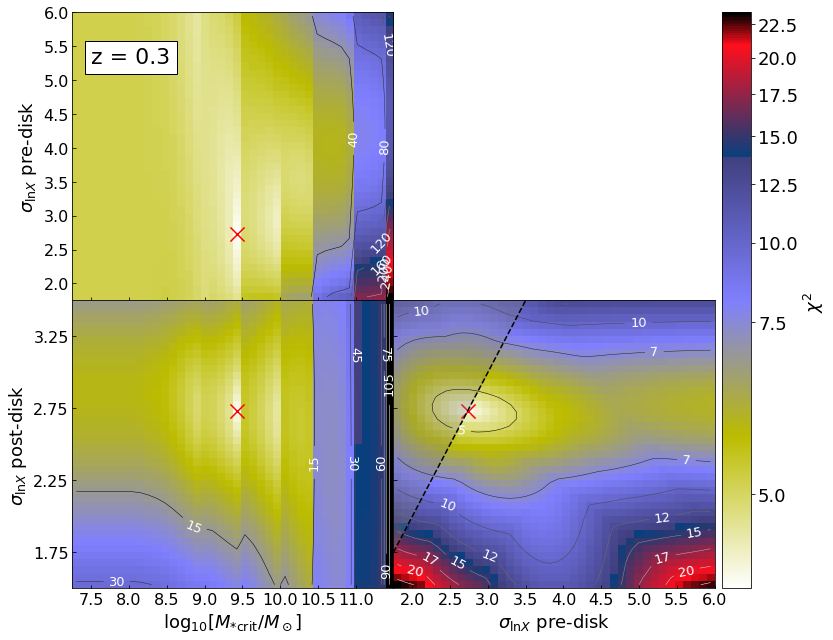

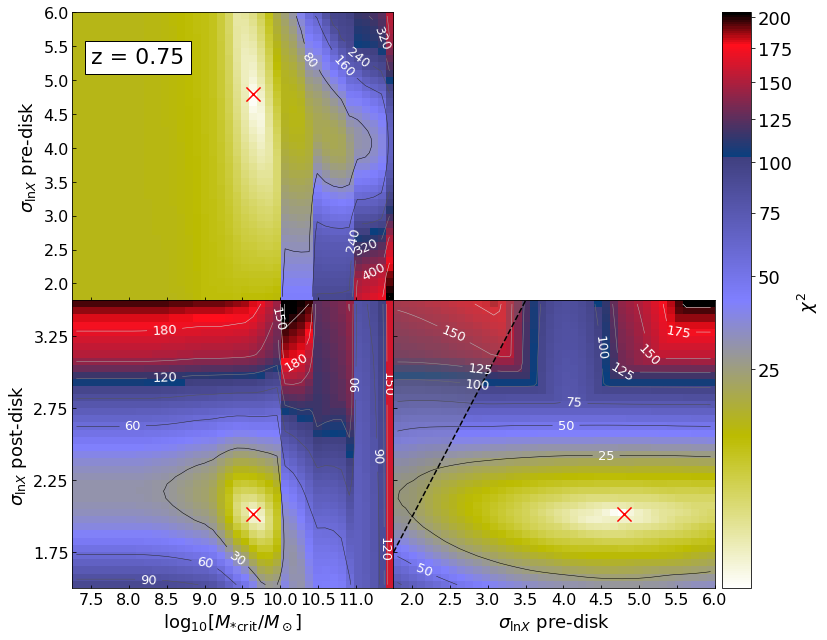

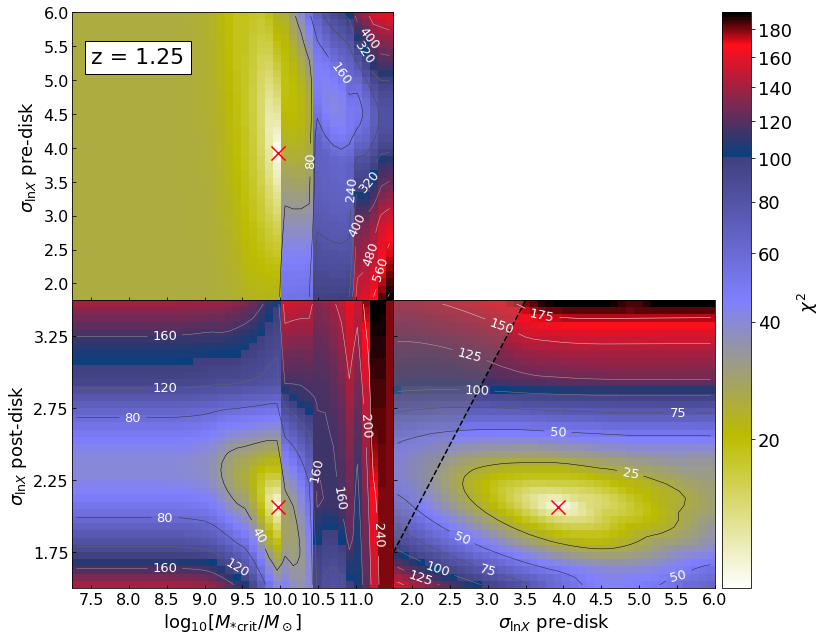

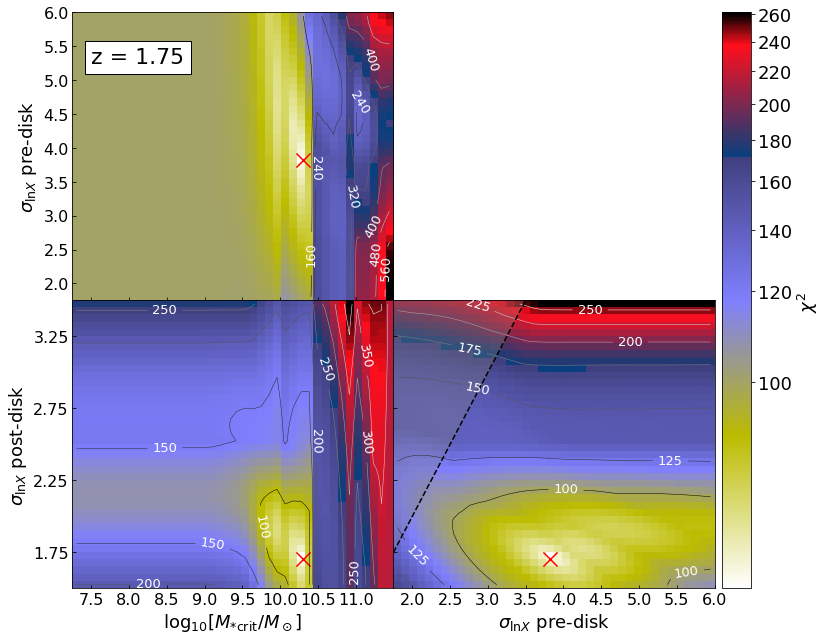

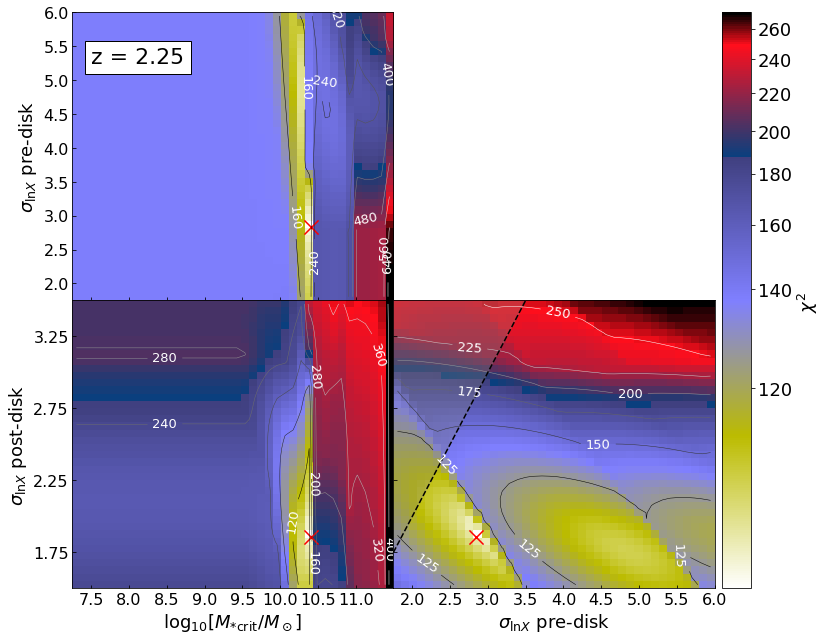

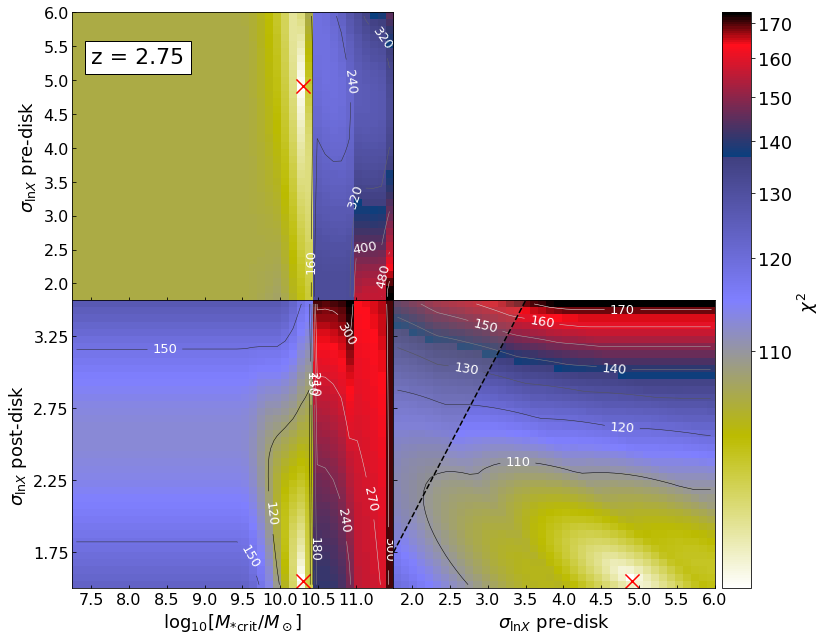

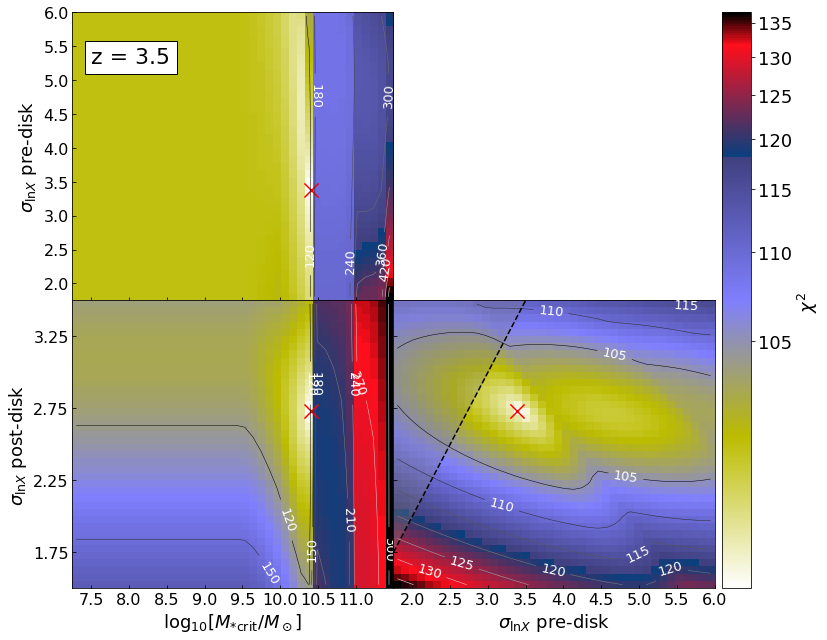

In [2]:
##### using GLOBAL MIN
def CHI2_POSTvsCRIT(z, FILE = "output/chi2_3pARIDfit_40_yw_mk2_plusz.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                     
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    extents = [[logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]]
        
    xlabels = ['', r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\sigma_{\ln{X}}$ post-disk', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[7.25,11.5,1.75,6.0],[7.25,11.5,1.5,3.5],[1.75,6.0,1.5,3.5]]
    vmin = [400, 500, 500]
    vmax = [2000, 2000, 2000]
    xticks = [[7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], [7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], np.linspace(2,6,9)]
    yticks = [np.linspace(2,6,9),[1.75,2.25,2.75,3.25],[1.75,2.25,2.75,3.25]]                     
    for ind, i, j in zip(range(3), axi, axj):
        
        f = h5py.File(FILE, "r")
        file = 'plots/FINAL_paper_plots/CHI2_ARID_z'+'-'.join(str(z).split('.'))+'.pdf'
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
#         minval = min(np.sum(chi23d, axis=axiss[ind]))
#         minIND = np.where((np.sum(chi23d, axis=axiss[ind]) == minval))[0][0]
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)

        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
                     
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel, fontsize=18)
        ax.set_ylabel(ylabel, fontsize=18)
        ax.axis(axis)
        ax.tick_params(axis='both', which='both', labelsize=16, direction='in')

        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 1:
#             grid2d = chi23d[:,minIND,:]
            grid2d = chi23d[:,minind[1][0],:]
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
#             grid2d = chi23d[:,:,minIND]
            grid2d = chi23d[:,:,minind[2][0]]
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 0:
#             grid2d = chi23d[minIND,:,:]
            grid2d = chi23d[minind[0][0],:,:]
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)

            
        norm = colors.LogNorm()
        norm=colors.PowerNorm(gamma=0.4)
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm = norm)
        cont = ax.contour(grid2d, extent = extent, cmap='binary_r', origin = 'image',linewidths=.5)
        plt.clabel(cont, inline=True, fontsize=13, colors='w', fmt = '%d')
     
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l)
    cbar.set_label(label=r'$\chi ^2$ ',size=18)
    cbar.ax.tick_params(labelsize=18)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    axes_l[0].text(7.5,5.25,'z = '+str(z), bbox=props, fontsize=22)
    axes_l[2].plot(np.linspace(1.75,6,5),np.linspace(1.75,6,5), linestyle = 'dashed',c='k')
    axes_l[2].fill_between(np.linspace(1.75,6,5), np.linspace(1.75,6,5), np.linspace(1.75,6,5)+20, color='gray', alpha=.3)
    plt.savefig(file)

for z in [0.3,0.75,1.25,1.75,2.25,2.75,3.5]:
    CHI2_POSTvsCRIT(z=z)


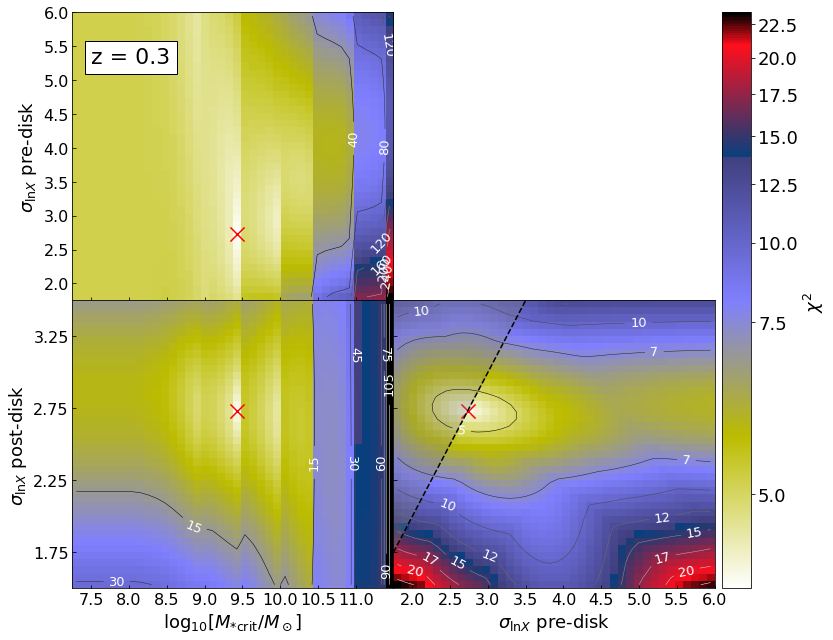

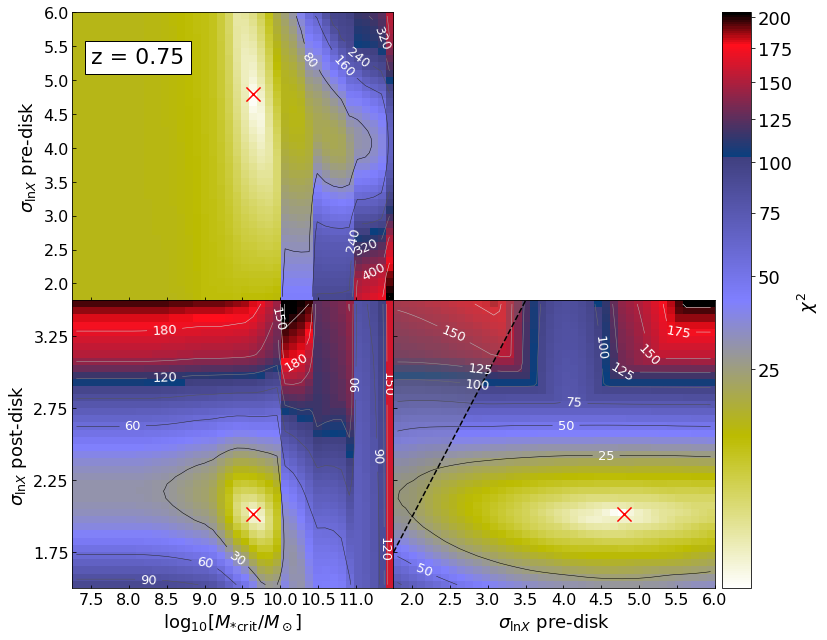

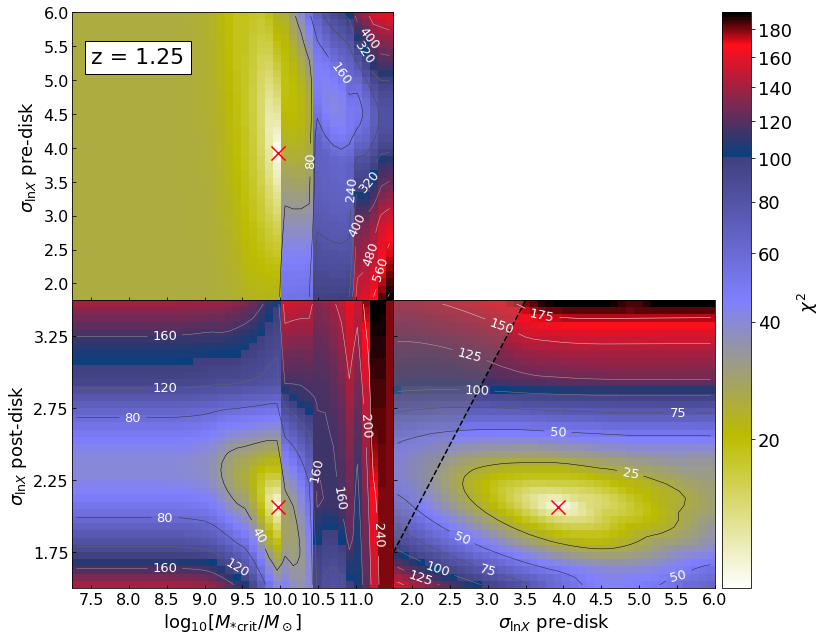

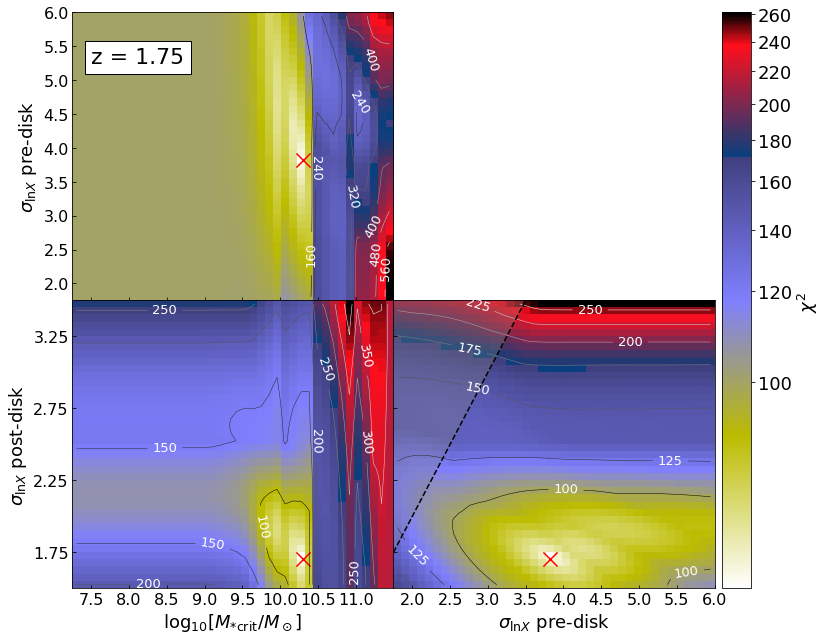

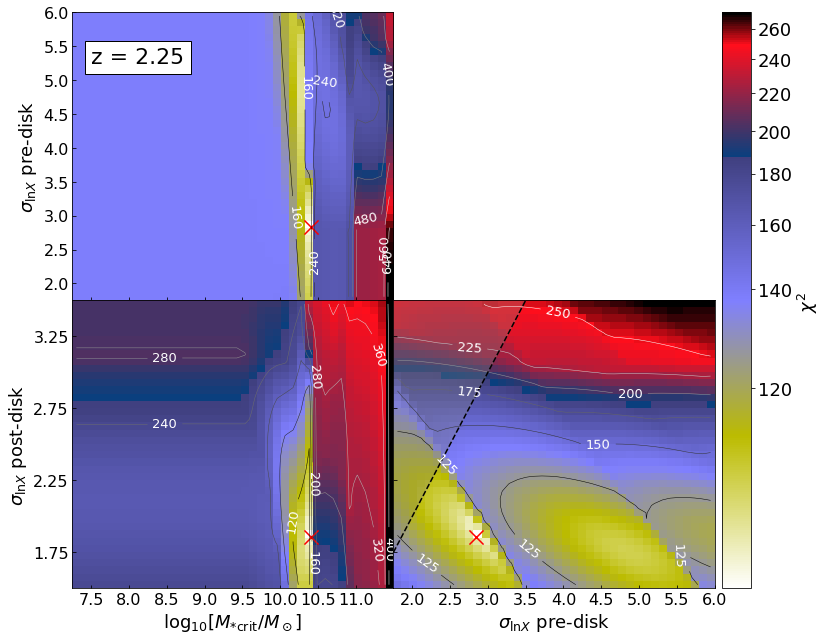

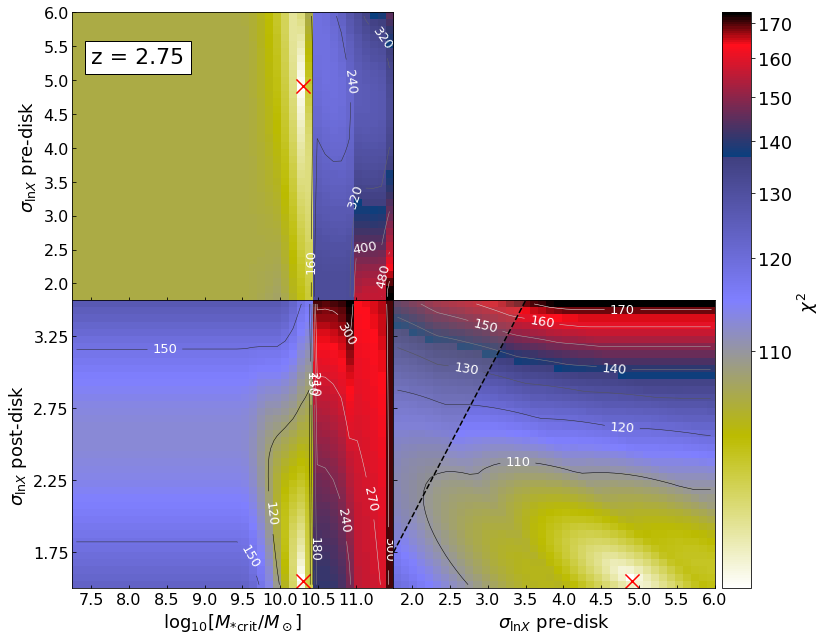

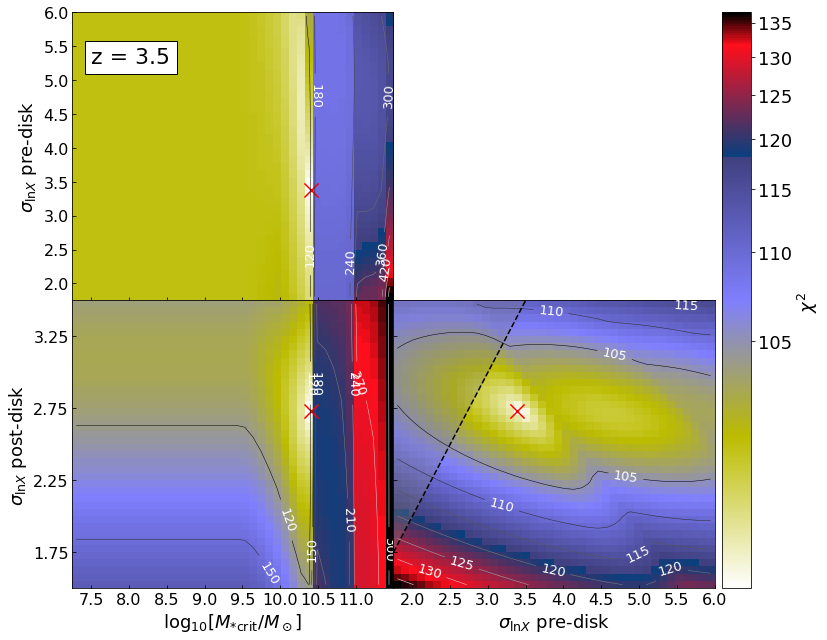

In [2]:
#### USING PER PIXEL OP
from functions import *
def CHI2_POSTvsCRIT(z, FILE = "output/chi2_3pARIDfit_40_yw_mk2_plusz.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                     
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    extents = [[logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]]
        
    xlabels = ['', r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\sigma_{\ln{X}}$ post-disk', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[7.25,11.5,1.75,6.0],[7.25,11.5,1.5,3.5],[1.75,6.0,1.5,3.5]]
    vmin = [400, 500, 500]
    vmax = [2000, 2000, 2000]
    xticks = [[7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], [7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], np.linspace(2,6,9)]
    yticks = [np.linspace(2,6,9),[1.75,2.25,2.75,3.25],[1.75,2.25,2.75,3.25]]                     
    for ind, i, j in zip(range(3), axi, axj):
        
        f = h5py.File(FILE, "r")
        file = 'plots/paper-plots/CHI2_ARID_ind-pixel-op_z'+'-'.join(str(z).split('.'))+'.pdf'
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
#         minval = min(np.sum(chi23d, axis=axiss[ind]))
#         minIND = np.where((np.sum(chi23d, axis=axiss[ind]) == minval))[0][0]
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)

        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
                     
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel, fontsize=18)
        ax.set_ylabel(ylabel, fontsize=18)
        ax.axis(axis)
        ax.tick_params(axis='both', which='both', labelsize=16, direction='in')

        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 1:
            grid2d = np.array(chi23d[:,minind[1][0],:])*0
            for i, l in enumerate(grid2d):
                for j in range(len(l)):
                    min3 = np.argmin(chi23d[i,:,j])
                    grid2d[i,j] = chi23d[i, min3, j]
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
            
        elif sums[ind] == 2:
            grid2d = np.array(chi23d[:,:,minind[2][0]])*0
            for i, l in enumerate(grid2d):
                for j in range(len(l)):
                    min3 = np.argmin(chi23d[i,j,:])
                    grid2d[i,j] = chi23d[i, j, min3]
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
            
        elif sums[ind] == 0:
            grid2d = np.array(chi23d[minind[0][0],:,:])*0
            for i, l in enumerate(grid2d):
                for j in range(len(l)):
                    min3 = np.argmin(chi23d[:,i,j])
                    grid2d[i,j] = chi23d[min3, i, j]
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)

            
        norm = colors.LogNorm()
        norm = colors.PowerNorm(gamma=0.4)
        img = ax.imshow(grid2d, cmap = 'gist_stern_r', interpolation = 'nearest', aspect='auto', extent = extent, norm = norm)
        cont = ax.contour(grid2d, extent = extent, cmap='binary_r', origin = 'image',linewidths=.5)
        plt.clabel(cont, inline=True, fontsize=13, colors='w', fmt = '%d')
     
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l)
    cbar.set_label(label=r'$\chi ^2$ ',size=18)
    cbar.ax.tick_params(labelsize=18)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    axes_l[0].text(7.5,5.25,'z = '+str(z), bbox=props, fontsize=22)
    axes_l[2].plot(np.linspace(1.75,6,5),np.linspace(1.75,6,5), linestyle = 'dashed',c='k')
    axes_l[2].fill_between(np.linspace(1.75,6,5), np.linspace(1.75,6,5), np.linspace(1.75,6,5)+20, color='gray', alpha=.3)
    plt.savefig(file)

for z in [0.3,0.75,1.25,1.75,2.25,2.75,3.5]:
    CHI2_POSTvsCRIT(z=z)


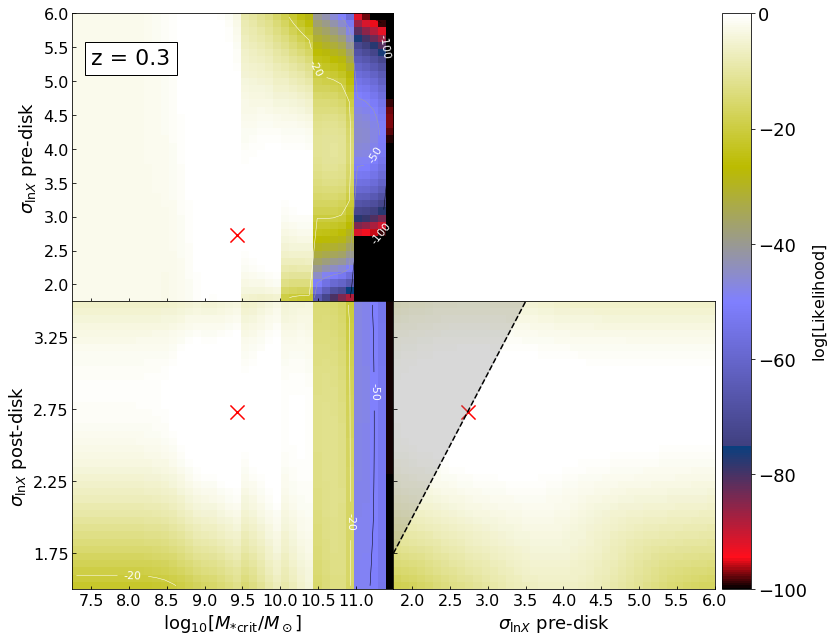

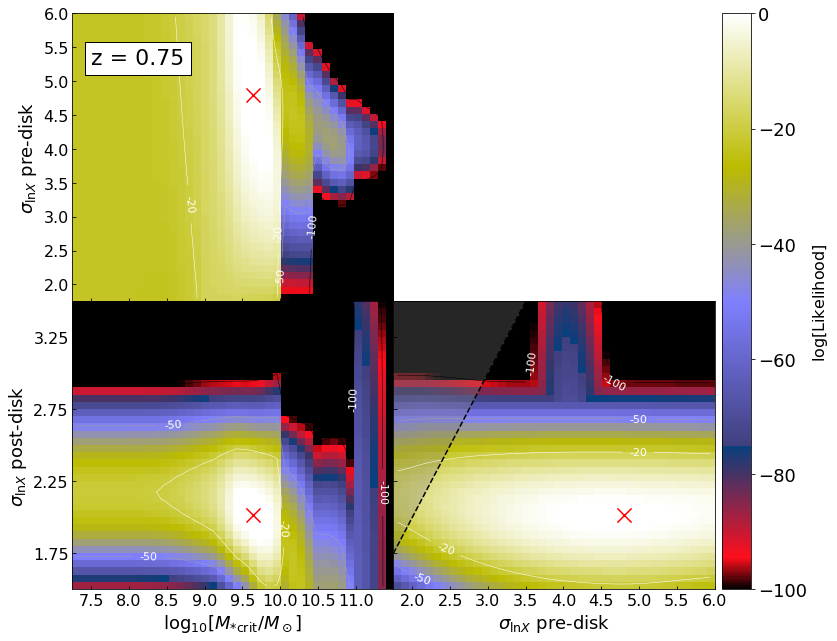

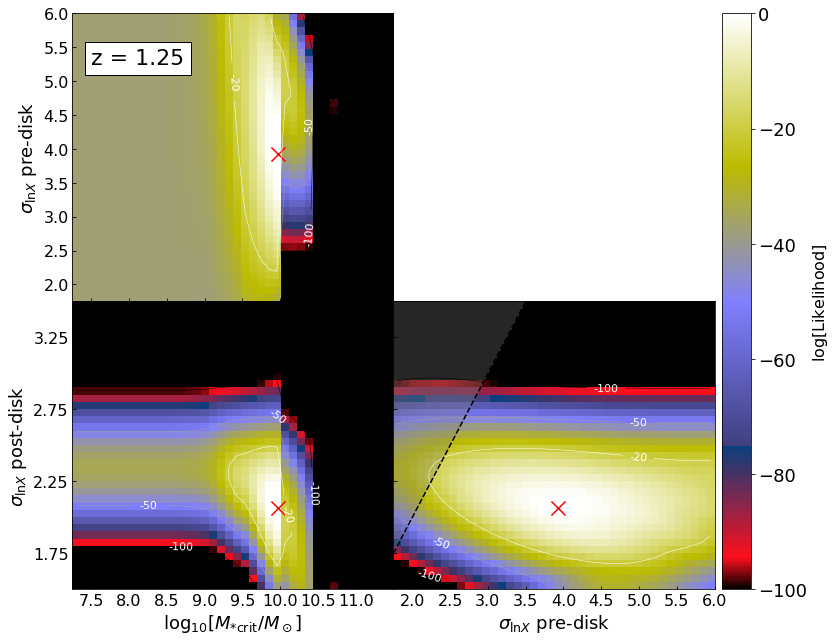

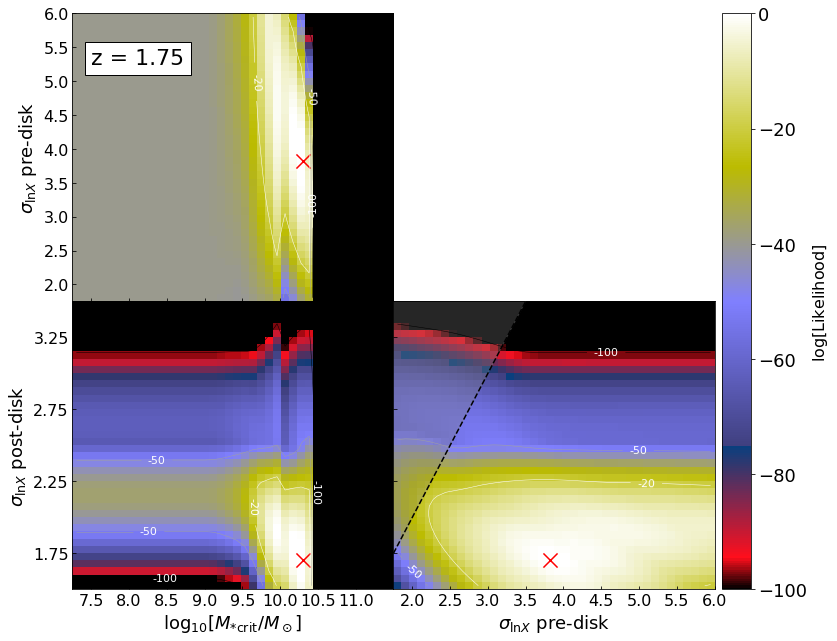

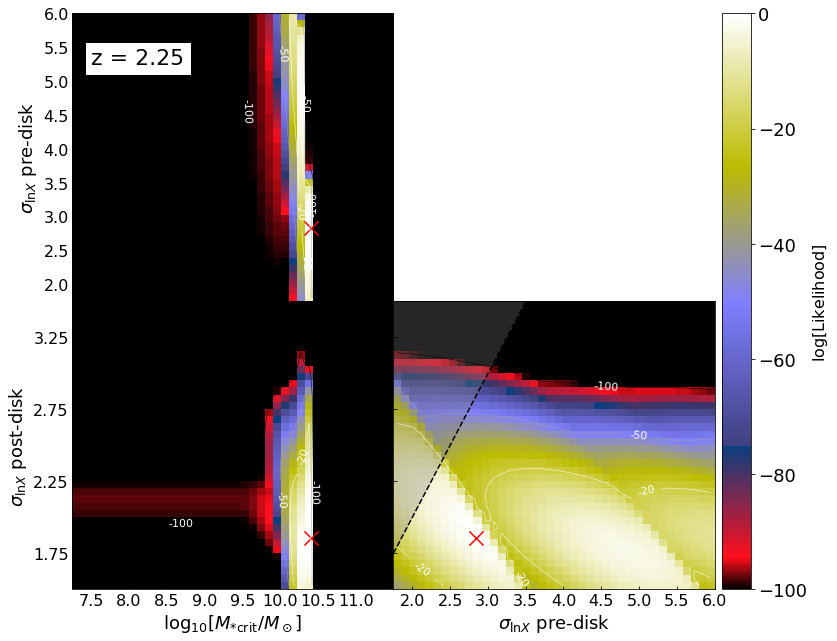

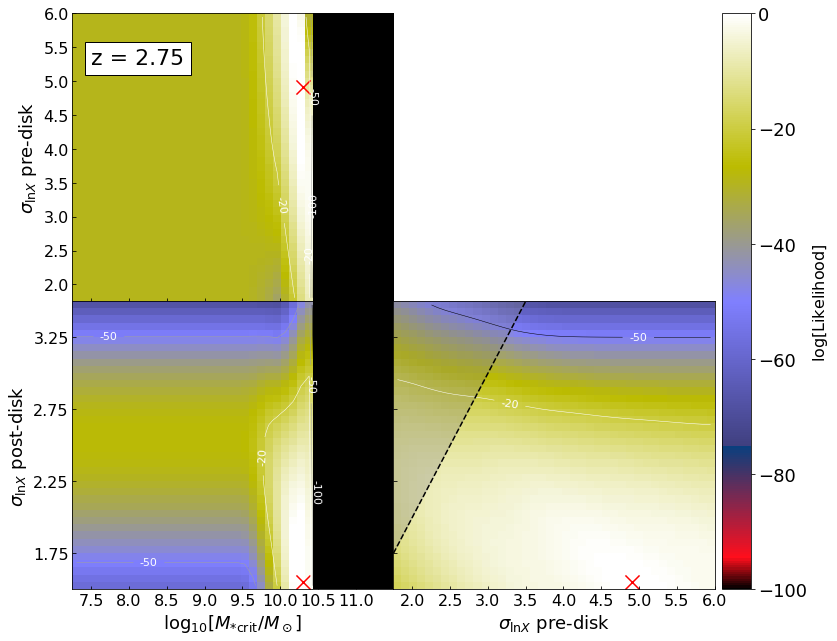

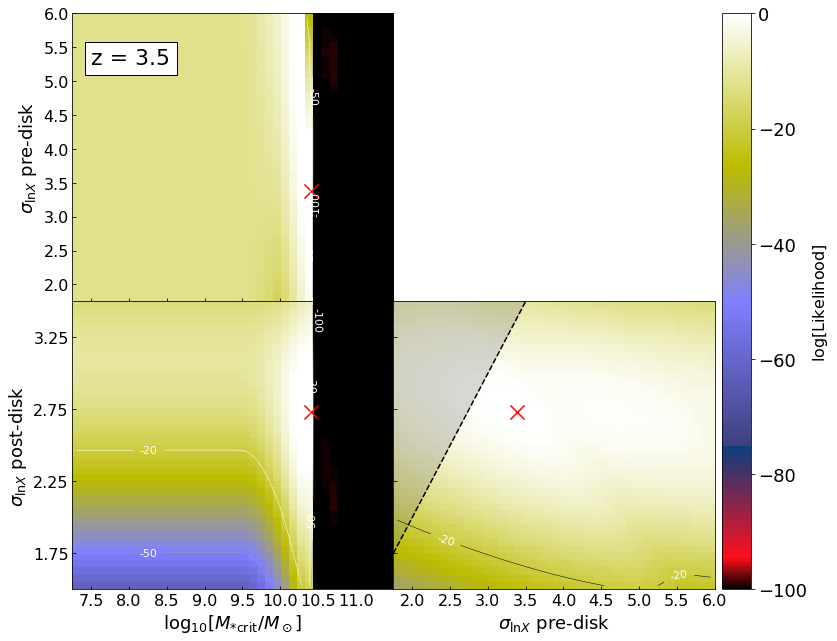

In [11]:
###USING LIKELIHOOD
from functions import *
def CHI2_POSTvsCRIT(z, FILE = "output/chi2_3pARIDfit_40_yw_mk2_plusz.h5py"):
    fig = plt.figure(figsize=(12,9))
    gs = gridspec.GridSpec(2, 2)
    
    
    f = h5py.File(FILE, "r")
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()
                     
    axj = [0,0,1]
    axi = [0,1,1]
    axes_l = []
    props = dict(boxstyle='square', facecolor='white', alpha=1)


    extents = [[logMstar0[0], logMstar0[-1], siglnX1[-1], siglnX1[0]],\
               [logMstar0[0], logMstar0[-1], siglnX2[-1], siglnX2[0]],\
               [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]]
        
    xlabels = ['', r'$\log_{10} [M_{*\rm{crit}}/M_\odot]$', r'$\sigma_{\ln{X}}$ pre-disk']
    ylabels = [r'$\sigma_{\ln{X}}$ pre-disk', r'$\sigma_{\ln{X}}$ post-disk', '']
    axiss = [(1,2),(0,2),(0,1)]
    sums = [0,1,2]
    axess = [[7.25,11.5,1.75,6.0],[7.25,11.5,1.5,3.5],[1.75,6.0,1.5,3.5]]
    vmin = [400, 500, 500]
    vmax = [2000, 2000, 2000]
    xticks = [[7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], [7.5,8.0,8.5,9.0,9.5,10.0,10.5,11.0], np.linspace(2,6,9)]
    yticks = [np.linspace(2,6,9),[1.75,2.25,2.75,3.25],[1.75,2.25,2.75,3.25]]                     
    for ind, i, j in zip(range(3), axi, axj):
        
        f = h5py.File(FILE, "r")
        file = 'plots/paper-plots/CHI2_ARID_likelihood-sum_z'+'-'.join(str(z).split('.'))+'.pdf'
        chi23d = f['z='+str(z)+'/chi23d_grid'][:].T
        f.close()
        
#         minval = min(np.sum(chi23d, axis=axiss[ind]))
#         minIND = np.where((np.sum(chi23d, axis=axiss[ind]) == minval))[0][0]
        
        minval = np.amin(chi23d)
        minind = np.where(chi23d == minval)

        bestpost = siglnX2[minind[0][0]]
        bestpre = siglnX1[minind[1][0]]
        bestcrit = logMstar0[minind[2][0]]
                     
        ### set up axis and label info
        ylabel = ylabels[ind]
        xlabel = xlabels[ind]
        axis = axess[ind]
        extent = extents[ind]

                     
        ax = fig.add_subplot(gs[i, j])
        axes_l += [ax]
        ax.set_xlabel(xlabel, fontsize=18)
        ax.set_ylabel(ylabel, fontsize=18)
        ax.axis(axis)
        ax.tick_params(axis='both', which='both', labelsize=16, direction='in')

        
        plt.setp(ax, xticks=xticks[ind],yticks=yticks[ind])
        
        if sums[ind] == 1:
#             grid2d = chi23d[:,minIND,:]
            grid2d = np.sum(np.e**(-chi23d+minval), axis = 1)
            ax.scatter(bestcrit, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 2:
#             grid2d = chi23d[:,:,minIND]
            grid2d = np.sum(np.e**(-chi23d+minval), axis = 2)
            ax.scatter(bestpre, bestpost, marker = 'x', c='r',s=200)
        elif sums[ind] == 0:
#             grid2d = chi23d[minIND,:,:]
            grid2d = np.sum(np.e**(-chi23d+minval), axis = 0)
            ax.scatter(bestcrit, bestpre, marker = 'x', c='r',s=200)
    

        grid2d = np.log(grid2d)
        grid2d[(grid2d == -np.inf)] = -1000


        img = ax.imshow(grid2d, cmap = 'gist_stern', interpolation = 'nearest', aspect='auto', extent = extent, vmin = -100, vmax = 0)#, norm = norm)#, vmin = 10e-300, vmax = 10e-224)

        cont = ax.contour(grid2d, extent = extent, cmap='binary_r', origin = 'image',linewidths=.5, levels = [-100, -50, -20])
        plt.clabel(cont, inline=True, fontsize=11, colors='w', fmt = '%d')
     
    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    cbar = plt.colorbar(img, label=r'$\chi ^2$ ', pad = 0.01, ax = axes_l)
    cbar.set_label(label=r'$\log$[Likelihood]',size=16)
    cbar.ax.tick_params(labelsize=18)
    plt.setp(axes_l[0].get_xticklabels(), visible=False)    
    plt.setp(axes_l[2].get_yticklabels(), visible=False)
    axes_l[0].text(7.5,5.25,'z = '+str(z), bbox=props, fontsize=22)
    axes_l[2].plot(np.linspace(1.75,6,5),np.linspace(1.75,6,5), linestyle = 'dashed',c='k')
    axes_l[2].fill_between(np.linspace(1.75,6,5), np.linspace(1.75,6,5), np.linspace(1.75,6,5)+20, color='gray', alpha=.3)
    plt.savefig(file)

for z in [0.3,0.75,1.25,1.75,2.25,2.75,3.5]:
    CHI2_POSTvsCRIT(z=z)


In [20]:
from functions import *
import h5py
import itertools
import numpy as np
import scipy as sp
import scipy.stats
from numpy.polynomial import chebyshev as C
import timeit
import warnings

warnings.filterwarnings("ignore")

#### this collects the arid duty data
duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []
### read through file
for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
        per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
### collect the error values
yerr = np.zeros([2,len(el)])
yerr[0,:], yerr[1,:] = el, eh
### set up mass bins and list of z values to evaluate
mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))
### set up duty arid data to compare
DUTY_ARID = np.zeros((len(mass),len(ztot)))
DUTY_ARID_errup = np.zeros((len(mass),len(ztot)))
DUTY_ARID_errdown = np.zeros((len(mass),len(ztot)))
aveETA_ARID = np.zeros((len(mass)-2, len(ztot)))
aveETA_ARID_errup = np.zeros((len(mass)-2, len(ztot)))
aveETA_ARID_errdown =  np.zeros((len(mass)-2, len(ztot)))
###
### collect duty for compare
for m, i in zip(mass, range(len(mass))):
    ind = np.where(np.array(ml) == m)[0]
    DUTY_ARID[i,0:len(ind)] = np.array(per)[ind]
    DUTY_ARID_errup[i,0:len(ind)] = yerr[1,ind]
    DUTY_ARID_errdown[i,0:len(ind)] = yerr[0,ind]
###
### collect ave eta for compare
colors = ['teal', 'gold', 'brown', 'r']
for i, c in zip(range(len(mass)-2), colors):
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for line in duty_arid.readlines():
        s = line.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    aveETA_ARID[i,0:len(x)] = np.array(y)
    aveETA_ARID_errup[i,0:len(x)] = np.array(yerrup)
    aveETA_ARID_errdown[i,0:len(x)] = np.array(yerrdown)
    duty_arid.close()  

DUTY_ARID = np.log10(DUTY_ARID)
DUTY_ARID_errup = np.log10(DUTY_ARID_errup)
DUTY_ARID_errdown = np.log10(DUTY_ARID_errdown)
criteria = np.log(0.01)


reso = 2
b = 0.005
SIG_lnMs = 0.7
L = np.linspace(5,18,100)



def get_chi2(ym, ya, err_abv, err_blw):
    abv = (ym[ym > ya] - ya[ym > ya])**2 / err_abv[ym > ya]**2
    blw = (ym[ym < ya] - ya[ym < ya])**2 / err_blw[ym < ya]**2
    abv[np.where((abv>80.))] = 80.
    blw[np.where((blw>80.))] = 80.
    return np.sum(abv) + np.sum(blw)


def partial_chi2(combo):
    pre, post, Ms_crit = combo[1], combo[2], combo[0]
    qlf.get_Mbh(Ms_crit, approx_local=True)
    qlf.get_dNdlnL(L, [pre, post])
    
    DUTY = np.zeros(len(mass))
    aveETA = np.zeros((len(mass)-2))

    MdotBH = qlf.MdotBH
    MU_MdotBH = qlf.Mdot_mu_sig[:,0]
    SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
    lnMs = qlf.StellBins
    dNdlnMstar = qlf.dNdlnMstar

    lnLbol = np.log(10**L*3.83e33) #log of erg/s
    MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s
    
    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol[ind] - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda)**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[lnlambda>=criteria]*dNdlnMstar[ind], x=lnlambda[lnlambda>=criteria])
        aveeta = np.sum(y[lnlambda>=criteria]*np.e**lnlambda[lnlambda>=criteria]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    Mcount = 0
    for Ms in mass:
        inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
        lnMstar = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
        h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
        for i in inds:
            dut, eta = dut_eta(lnMs[i], i)
            DUTY[Mcount] += dut*h
            if Mcount >= 2:
                aveETA[Mcount-2] += eta*h
        if Mcount >= 2:
            aveETA[Mcount-2] = aveETA[Mcount-2]/DUTY[Mcount]
        DUTY[Mcount] = DUTY[Mcount]/lnMstar
        Mcount += 1

    DUTY = np.log10(DUTY*100)
    aveETA = np.log10(aveETA)
    
    chi2 = 0
    ym, ya = DUTY[dutyinds], DUTY_ARID[:,zcount][dutyinds]
    err_abv, err_blw = DUTY_ARID_errup[:,zcount][dutyinds], DUTY_ARID_errdown[:,zcount][dutyinds]
    chi2 += get_chi2(ym, ya, err_abv, err_blw)
    ym, ya = aveETA[etainds], aveETA_ARID[:,zcount][etainds]
    err_abv, err_blw = aveETA_ARID_errup[:,zcount][etainds], aveETA_ARID_errdown[:,zcount][etainds]
    chi2 += get_chi2(ym, ya, err_abv, err_blw)
    return chi2

logMstar0 = np.linspace(8.5,11.5,reso)
xsigpre = np.linspace(2.0,4.0,reso)
xsigpost = np.linspace(1.5,3.5,reso)
combos = np.array(list(itertools.product(logMstar0, xsigpre, xsigpost)))


#### loop through z values first because it saves time

chi2_matrix = np.zeros((reso, reso, reso))
zcount = 0
for z in ztot:
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    dutyinds = np.where((DUTY_ARID[:,zcount] != -np.inf))
    etainds = np.where((aveETA_ARID[:,zcount] != -np.inf))
    chi2_matrix_part = np.apply_along_axis(partial_chi2, 1, combos).reshape(reso,reso,reso)
    chi2_matrix += chi2_matrix_part
    print(chi2_matrix)
    zcount += 1
print(np.shape(chi2_matrix))

[[[ 30.41685781  14.89361988]
  [ 29.48931789  13.98863286]]

 [[236.788649   236.45813752]
  [110.73434106 110.34511418]]]
[[[128.15158709 196.63669661]
  [126.1058763  194.5747619 ]]

 [[693.35693431 692.1949789 ]
  [262.83399665 262.4431054 ]]]
[[[ 318.61246306  370.84153669]
  [ 316.5644861   368.77745877]]

 [[1210.25337895 1207.94980263]
  [ 547.97384217  547.53968871]]]
[[[ 519.66345522  612.33235702]
  [ 517.61547825  610.26827909]]

 [[1711.12896224 1705.78524057]
  [ 864.15095932  863.5266675 ]]]
[[[ 715.16609641  850.43435667]
  [ 713.11811945  848.37027875]]

 [[2262.00960151 2253.85787646]
  [1235.63583899 1234.65862593]]]
[[[ 858.87478076 1003.79955372]
  [ 856.8268038  1001.73547579]]

 [[2747.35319232 2738.39362209]
  [1516.73686271 1515.40942148]]]
[[[1005.14012781 1102.05014818]
  [1003.09215085 1099.98607026]]

 [[3217.92488572 3206.96895671]
  [1803.49361101 1801.7325624 ]]]
(2, 2, 2)


In [24]:
import itertools
reso = 10
logMstar0 = np.linspace(8.5,11.5,reso)
xsigpre = np.linspace(2.0,4.0,reso)
xsigpost = np.linspace(1.5,3.5,reso)
combos = np.array(list(itertools.product(logMstar0, xsigpre, xsigpost)))
print(combos)

[[ 8.5         2.          1.5       ]
 [ 8.5         2.          1.72222222]
 [ 8.5         2.          1.94444444]
 ...
 [11.5         4.          3.05555556]
 [11.5         4.          3.27777778]
 [11.5         4.          3.5       ]]


In [114]:
import itertools
a = np.array(list(itertools.product(['m1','m2'], ['r1','r2'], ['p1','p2'])))

print(a.reshape(2,2,2,3))

b = np.array([1,2,3,4,5,6,7,8]).reshape(2,2,2)

print(b.T[0,:,:])# first index is the post disk sigma x is mstar crit y is predisk
print(b.T[:,0,:])# second index is the pre disk sigma x is mstar crit y is post disk
print(b.T[:,:,0])# third index is the mstar crit x is pre disk sigma y is post disk

[[[['m1' 'r1' 'p1']
   ['m1' 'r1' 'p2']]

  [['m1' 'r2' 'p1']
   ['m1' 'r2' 'p2']]]


 [[['m2' 'r1' 'p1']
   ['m2' 'r1' 'p2']]

  [['m2' 'r2' 'p1']
   ['m2' 'r2' 'p2']]]]
[[1 5]
 [3 7]]
[[1 5]
 [2 6]]
[[1 3]
 [2 4]]


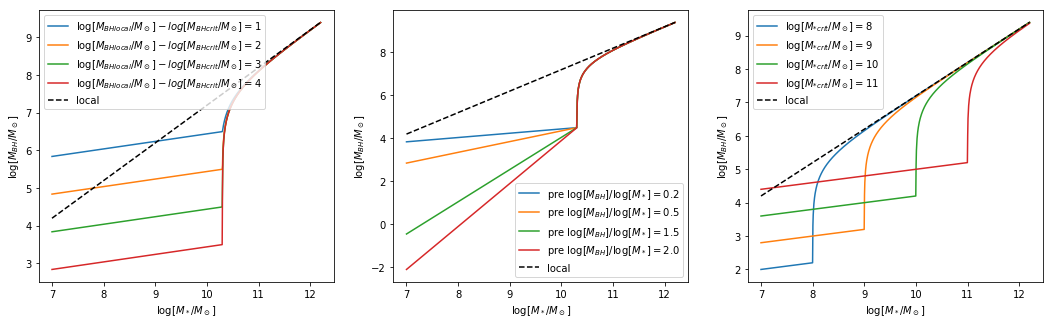

In [23]:
from functions_newparams import *

fig = plt.figure(figsize=(18,5))
gs = gridspec.GridSpec(1, 3)


pre, post, SIG_lnMs, Ms_crit, b = 4.4, 1.7, 0.7, 10.3, 0.005
slope_low, norm_from_local = .2, 3.0
L = np.linspace(5,18,200)
z = 1.0
norm = [11, 8.2]

ax = fig.add_subplot(gs[0, 0])
for n in [1,2,3,4]:

    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(Ms_crit, slope_low, n, approx_local=True)
    qlf.get_dNdlnL(L, [pre, post])

    Mbh = qlf.BHBins
    Mstar = qlf.StellBins

    plt.plot(Mstar, Mbh, label = '$\log[M_{BHlocal}/M_\odot]-log[M_{BHcrit}/M_\odot] = $'+str(n))
    plt.xlabel('$\log[M_*/M_\odot]$')
    plt.ylabel('$\log[M_{BH}/M_\odot]$')
plt.plot(Mstar, Mstar-2.8,c='k',linestyle='dashed',label='local')
plt.legend()
    
ax = fig.add_subplot(gs[0, 1])
for s in [0.2, 0.5, 1.5, 2.0]:
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(Ms_crit, s, norm_from_local, approx_local=True)
    qlf.get_dNdlnL(L, [pre, post])

    Mbh = qlf.BHBins
    Mstar = qlf.StellBins

    plt.plot(Mstar, Mbh, label = 'pre $\log[M_{BH}]/\log[M_*] = $'+str(s))
    plt.xlabel('$\log[M_*/M_\odot]$')
    plt.ylabel('$\log[M_{BH}/M_\odot]$')
plt.plot(Mstar, Mstar-2.8,c='k',linestyle='dashed',label='local')
plt.legend()
    
ax = fig.add_subplot(gs[0, 2])
for m in [8, 9, 10, 11]:
    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(m, slope_low, norm_from_local, approx_local=True)
    qlf.get_dNdlnL(L, [pre, post])

    Mbh = qlf.BHBins
    Mstar = qlf.StellBins

    plt.plot(Mstar, Mbh, label = '$\log[M_{*crit}/M_\odot] = $'+str(m))
    plt.xlabel('$\log[M_*/M_\odot]$')
    plt.ylabel('$\log[M_{BH}/M_\odot]$')
plt.plot(Mstar, Mstar-2.8,c='k',linestyle='dashed',label='local')
plt.legend()

plt.savefig('plots/paper-plots/new_param_effects.pdf')


516.3333317175479 (array([4]), array([24]), array([28]))
1.705128205128205 4.365384615384615 10.301282051282051


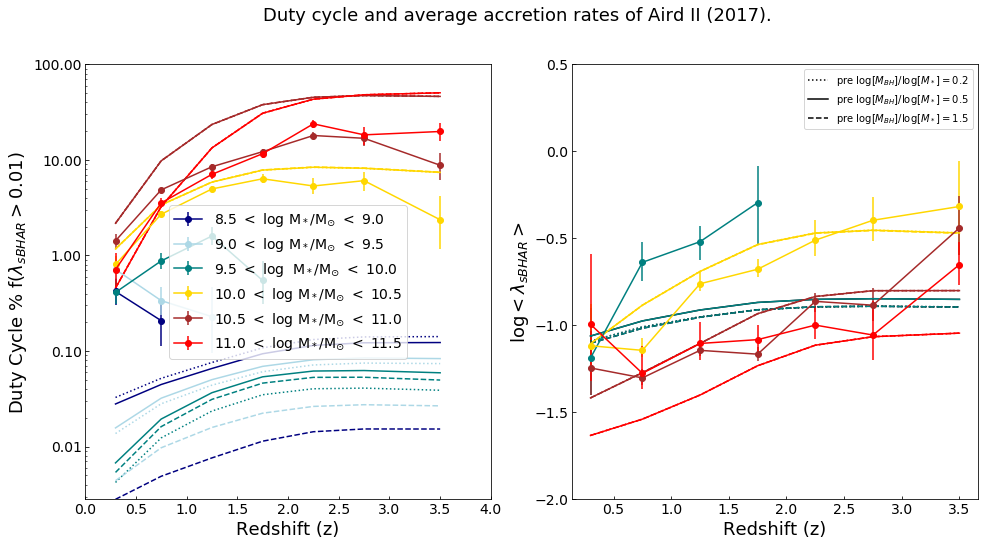

In [22]:
####### USING THEIR DEFINITION EXACTLY ##########
from functions_newparams import *
from matplotlib.ticker import FormatStrFormatter
# from matplotlib import rc
# rc('font',**{'family':'serif','serif':['Times']})
# rc('text', usetex=True)


f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
chi23d = f['chi23d_grid'][:].T
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
f.close()

minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
print(minval, minind)

bestpost = siglnX2[minind[0][0]]
bestpre = siglnX1[minind[1][0]]
bestcrit = logMstar0[minind[2][0]]

print(bestpost, bestpre, bestcrit)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,8))
fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']


duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
        per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

yerr = np.zeros([2,len(el)])
yerr[0,:], yerr[1,:] = el, eh

mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))

for i, c, l in zip(mass, colors, labels):
    ind = np.where(np.array(ml) == i)[0]
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = np.array(yerr)[:,ind]

    ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


for c in ['teal', 'gold', 'brown', 'r']:
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for i in duty_arid.readlines():
        s = i.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    yerr = np.zeros([2,len(yerrup)])
    yerr[0,:] = yerrdown
    yerr[1,:] = yerrup
    duty_arid.close()

    ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 

for s, ls in zip([.2, .5, 1.5],['dotted','solid','dashed']):
    # pre, post, SIG_lnMs, Ms_crit, b = 3.75, 2.0, 0.7, 10.25, 0.005
    pre, post, SIG_lnMs, Ms_crit, b = bestpre, bestpost, 0.7, bestcrit, 0.005
    slope_low, norm_from_local = s, 3.0


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        qlf.get_dNdlnL(L, [pre, post])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c, ls=ls)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k', label='pre $\log[M_{BH}]/\log[M_*] = $'+str(s), ls=ls)
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c, ls=ls)
        pcount+=1 
    
    

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.legend(fontsize = 14)

ax1.set_yscale('log')
ax1.set_xlim([0, 4])
ax1.set_ylim([0, 100])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    
ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.set_ylim([-2,0.5])
ax2.legend()

fig.savefig('plots/FINAL_paper_plots/AIRD_vary-pre-slope.pdf')


516.3333317175479 (array([4]), array([24]), array([28]))
1.705128205128205 4.365384615384615 10.301282051282051


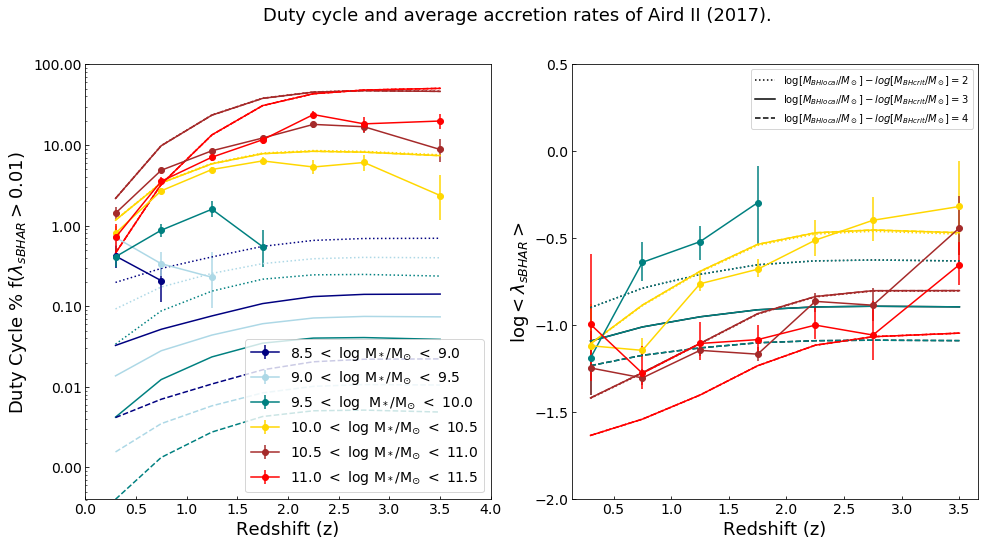

In [21]:
####### USING THEIR DEFINITION EXACTLY ##########
from functions_newparams import *
from matplotlib.ticker import FormatStrFormatter
# from matplotlib import rc
# rc('font',**{'family':'serif','serif':['Times']})
# rc('text', usetex=True)


f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
chi23d = f['chi23d_grid'][:].T
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
f.close()

minval = np.amin(chi23d)
minind = np.where(chi23d == minval)
print(minval, minind)

bestpost = siglnX2[minind[0][0]]
bestpre = siglnX1[minind[1][0]]
bestcrit = logMstar0[minind[2][0]]

print(bestpost, bestpre, bestcrit)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,8))
fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']


duty_arid = open("plot_data/fduty_vs_z.dat",'r')
all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

for i in duty_arid.readlines():
    s = i.split()
    if s[0] == 'All':
        zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
        per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

yerr = np.zeros([2,len(el)])
yerr[0,:], yerr[1,:] = el, eh

mass = [8.5,9.0,9.5,10.0,10.5,11.0]
ztot = sorted(set((np.array(zl) + np.array(zh))/2))

for i, c, l in zip(mass, colors, labels):
    ind = np.where(np.array(ml) == i)[0]
    z = (np.array(zl)[ind]+np.array(zh)[ind])/2
    dut = np.array(per)[ind]
    err = np.array(yerr)[:,ind]

    ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


for c in ['teal', 'gold', 'brown', 'r']:
    x = []
    y = []
    yerrup = []
    yerrdown = []
    duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
    for i in duty_arid.readlines():
        s = i.split()
        if s[0][0] != '#' and s[0] == c:
            x.append(float(s[1]))
            y.append(float(s[2]))
            yerrup.append(float(s[3])-float(s[2]))
            yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
    yerr = np.zeros([2,len(yerrup)])
    yerr[0,:] = yerrdown
    yerr[1,:] = yerrup
    duty_arid.close()

    ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 

for n, ls in zip([2, 3, 4],['dotted','solid','dashed']):
    # pre, post, SIG_lnMs, Ms_crit, b = 3.75, 2.0, 0.7, 10.25, 0.005
    pre, post, SIG_lnMs, Ms_crit, b = bestpre, bestpost, 0.7, bestcrit, 0.005
    slope_low, norm_from_local = 0.2, n


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        qlf.get_dNdlnL(L, [pre, post])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c, ls=ls)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k', label='$\log[M_{BHlocal}/M_\odot]-log[M_{BHcrit}/M_\odot] = $'+str(n), ls=ls)
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c, ls=ls)
        pcount+=1 
    
    

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)
ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax1.legend(fontsize = 14)

ax1.set_yscale('log')
ax1.set_xlim([0, 4])
ax1.set_ylim([0, 100])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    
ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)
ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')
ax2.set_ylim([-2,0.5])
ax2.legend()

fig.savefig('plots/FINAL_paper_plots/AIRD_vary-norm.pdf')


In [102]:
####### USING THEIR DEFINITION EXACTLY ##########
from functions_newparams import *
from matplotlib.ticker import FormatStrFormatter
# from matplotlib import rc
# rc('font',**{'family':'serif','serif':['Times']})
# rc('text', usetex=True)

def plot_duty(slope_low, norm_from_local, Ms_crit):

    f = h5py.File("output/chi2_3pARIDfit_40_yw_mk2.h5py", "r")
    chi23d = f['chi23d_grid'][:].T
    logMstar0 = f['logMstar0'][:]
    siglnX2 = f['siglnX2'][:]
    siglnX1 = f['siglnX1'][:]
    f.close()

    minval = np.amin(chi23d)
    minind = np.where(chi23d == minval)

    bestpost = siglnX2[minind[0][0]]
    bestpre = siglnX1[minind[1][0]]
    bestcrit = logMstar0[minind[2][0]]


    duty_arid = open("plot_data/fduty_vs_z.dat",'r')
    all_gal, zl, zh, ml, mh, per, el, eh = [], [], [], [], [], [], [], []

    for i in duty_arid.readlines():
        s = i.split()
        if s[0] == 'All':
            zl.append(float(s[1])), zh.append(float(s[2])), ml.append(float(s[3])), mh.append(float(s[4]))
            per.append(float(s[5])), el.append(float(s[6])), eh.append(float(s[7].split("\n")[0]))
        

    yerr = np.zeros([2,len(el)])
    yerr[0,:], yerr[1,:] = el, eh

    mass = [8.5,9.0,9.5,10.0,10.5,11.0]
    ztot = sorted(set((np.array(zl) + np.array(zh))/2))

    for i, c, l in zip(mass, colors, labels):
        ind = np.where(np.array(ml) == i)[0]
        z = (np.array(zl)[ind]+np.array(zh)[ind])/2
        dut = np.array(per)[ind]
        err = np.array(yerr)[:,ind]

        ax1.errorbar(z, dut, yerr = err, fmt='o-', color = c, label = l)


    for c in ['teal', 'gold', 'brown', 'r']:
        x = []
        y = []
        yerrup = []
        yerrdown = []
        duty_arid = open("plot_data/pledd_all_extracted.dat",'r')
        for i in duty_arid.readlines():
            s = i.split()
            if s[0][0] != '#' and s[0] == c:
                x.append(float(s[1]))
                y.append(float(s[2]))
                yerrup.append(float(s[3])-float(s[2]))
                yerrdown.append(float(s[2])-float(s[4].split("\n")[0]))
        yerr = np.zeros([2,len(yerrup)])
        yerr[0,:] = yerrdown
        yerr[1,:] = yerrup
        duty_arid.close()

        ax2.errorbar(x, y, yerr=yerr, fmt='o-', color = c) 
    
    pre, post, SIG_lnMs, b = bestpre, bestpost, 0.7, 0.005


    L = np.linspace(5,18,200) #log10 of solar luminosities

    count = 0

    DUTY_tot = np.zeros((len(mass),len(ztot)))
    aveETA_tot = np.zeros((len(mass)-2, len(ztot)))

    def dut_eta(Ms, ind):
        MU_lnlambda = MU_lnLbol - np.log(1.3e38*0.002*(10**Ms)) #log dimensionless
        lnlambda = lnLbol - np.log(1.3e38*0.002*(10**Ms))

        y = ( 1/np.sqrt(2.0 * np.pi * SIG_MdotBH[ind]**2.0) ) * np.exp( -(lnlambda - MU_lnlambda[ind])**2.0 / (2.0 * SIG_MdotBH[ind]**2) )
        duty = np.trapz(y[np.e**lnlambda>=0.01]*dNdlnMstar[ind], x=lnlambda[np.e**lnlambda>=0.01])
        aveeta = np.sum(y[np.e**lnlambda>=0.01]*np.e**lnlambda[np.e**lnlambda>=0.01]*(lnlambda[1]-lnlambda[0])*dNdlnMstar[ind])

        return duty, aveeta

    zcount = 0
    for z in ztot:
        qlf = QLF(z, b)
        qlf.get_dNdlnMstar(SIG_lnMs)
        qlf.get_Mbh(Ms_crit, slope_low, norm_from_local, approx_local=True)
        qlf.get_dNdlnL(L, [pre, post])

        MdotBH = qlf.MdotBH
        MU_MdotBH = qlf.Mdot_mu_sig[:,0]
        SIG_MdotBH = qlf.Mdot_mu_sig[:,1]
        lnMs = qlf.StellBins
        dNdlnMstar = qlf.dNdlnMstar

        lnLbol = np.log(10**L*3.83e33) #log of erg/s
        MU_lnLbol = MU_MdotBH + np.log(0.1 * (2.99e10)**2) #log of erg/s

        Mcount = 0
        for Ms in mass:
            inds = np.where((lnMs > Ms) & (lnMs < Ms+0.5))[0]
            lnMstar_tot = np.trapz(dNdlnMstar[inds], x=lnMs[inds])
            h = (lnMs[inds[-1]] - lnMs[inds[0]]) / len(inds)
            for i in inds:
                dut, eta = dut_eta(lnMs[i], i)
                DUTY_tot[Mcount,zcount] += dut*h
                if Mcount >= 2:
                    aveETA_tot[Mcount-2,zcount] += eta*h
            if Mcount >= 2:
                aveETA_tot[Mcount-2,zcount] = aveETA_tot[Mcount-2,zcount]/DUTY_tot[Mcount,zcount]
            DUTY_tot[Mcount,zcount] = DUTY_tot[Mcount,zcount]/lnMstar_tot
            Mcount += 1
        zcount += 1
    
    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    ax3.plot(Mstar, Mbh, color='r')

    pcount = 0
    for i, c in zip(range(0,len(mass)), colors):
        ax1.plot(ztot, DUTY_tot[i,:]*100, c=c)
        if pcount >= 2:
            if pcount == 2:
                ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c='k')
            ax2.plot(ztot, np.log10(aveETA_tot[i-2,:]), c=c)
        pcount+=1 
    
    

    
    ax1.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax1.set_yscale('log')
    ax1.set_xlim([0, 4])
    ax1.set_ylim([0, 100])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_ylim([-2,0.5])
    ax2.tick_params(axis='both', which='both', labelsize=14, direction='in')

    ax3.tick_params(axis='both', which='both', labelsize=14, direction='in')
    ax3.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='Local Scaling Relation')
    

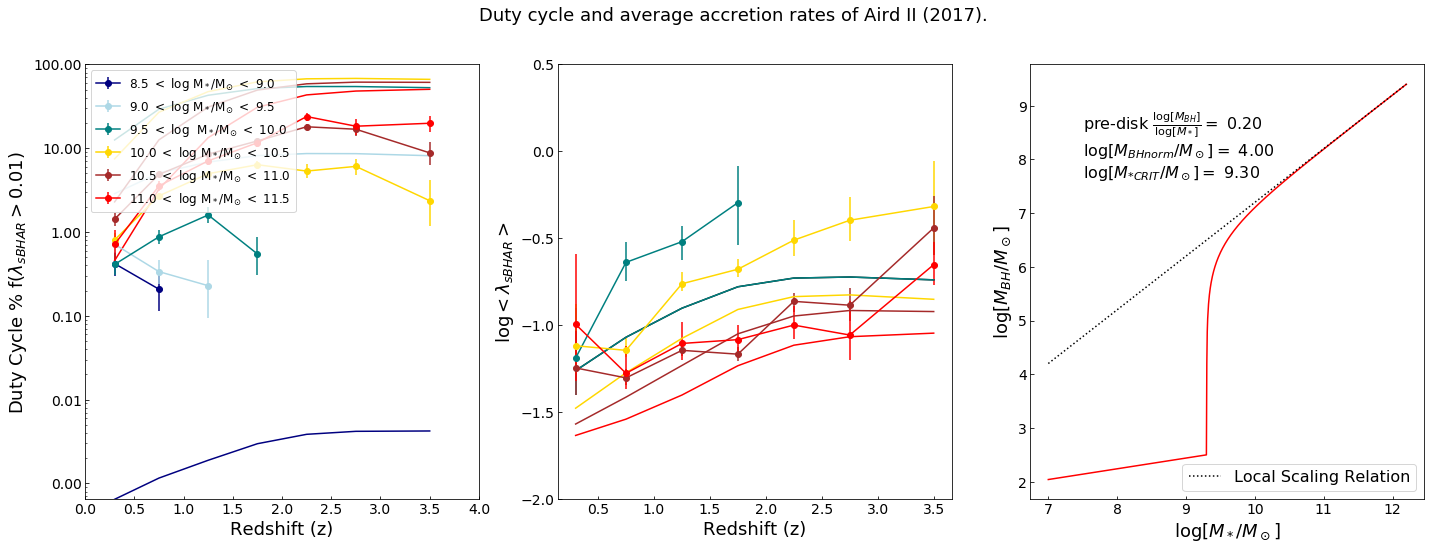

MovieWriter PillowWriter unavailable.


In [107]:
from matplotlib import pyplot as plt
from celluloid import Camera
import numpy as np

frames = 9
slopes, norms, crits = list(np.linspace(0.2,1.5,frames,endpoint=False)), list(np.linspace(4,1,frames,endpoint=False)), list(np.linspace(9.3,10.7,frames+frames/3,endpoint=False))
slopes.extend(np.linspace(1.5,1.0,frames/3)), norms.extend(np.linspace(1,0,frames/3))#, crits.extend(np.linspace(10.0,10.3,frames/3))


fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(24,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

camera = Camera(fig)
leg_count = 0

for s, n, m in zip(slopes,norms,crits):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
    leg_count += 1
    ax3.text(7.5,7.75,info,fontsize = 16)
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('params_v_duty.gif', writer='PillowWriter', fps=2)

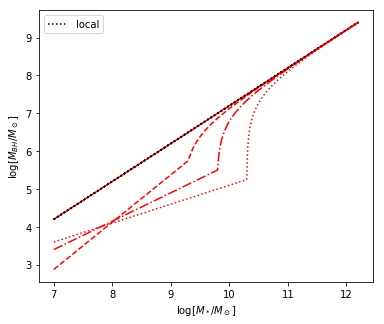

In [95]:
from functions_newparams import *

fig = plt.figure(figsize=(6,5))


pre, post, SIG_lnMs, Ms_crit, b = 4.4, 1.7, 0.7, 10.3, 0.005
slope_low, norm_from_local = .2, 3.0
L = np.linspace(5,18,200)
z = 1.0
norm = [11, 8.2]
plt.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted',label='local')
for n,s,m,ls in zip([0,.75,1.5,2.25],[1,1.25,.75,.5,.2],[10.3,9.3,9.8,10.3],['solid','dashed','dashdot','dotted']):

    qlf = QLF(z, b)
    qlf.get_dNdlnMstar(SIG_lnMs)
    qlf.get_Mbh(m, s, n, approx_local=True)
    qlf.get_dNdlnL(L, [pre, post])

    Mbh = qlf.BHBins
    Mstar = qlf.StellBins
    plt.plot(Mstar, Mstar-2.8,c='k',linestyle='dotted')
    
    plt.plot(Mstar, Mbh,ls=ls,color='r')
    plt.xlabel('$\log[M_*/M_\odot]$')
    plt.ylabel('$\log[M_{BH}/M_\odot]$')
plt.legend()

# plt.savefig('plots/paper-plots/new_param_effects_test.pdf')


In [74]:
a= 1.2345
print(" here is a string %.02f %.03f"%(a,a))

 here is a string 1.23 1.234


In [ ]:
from functions_newparams import *
o_pre, o_post, o_crit = 1.705128205128205, 4.365384615384615, 10.301282051282051
o_slope, o_norm = 0.2, 



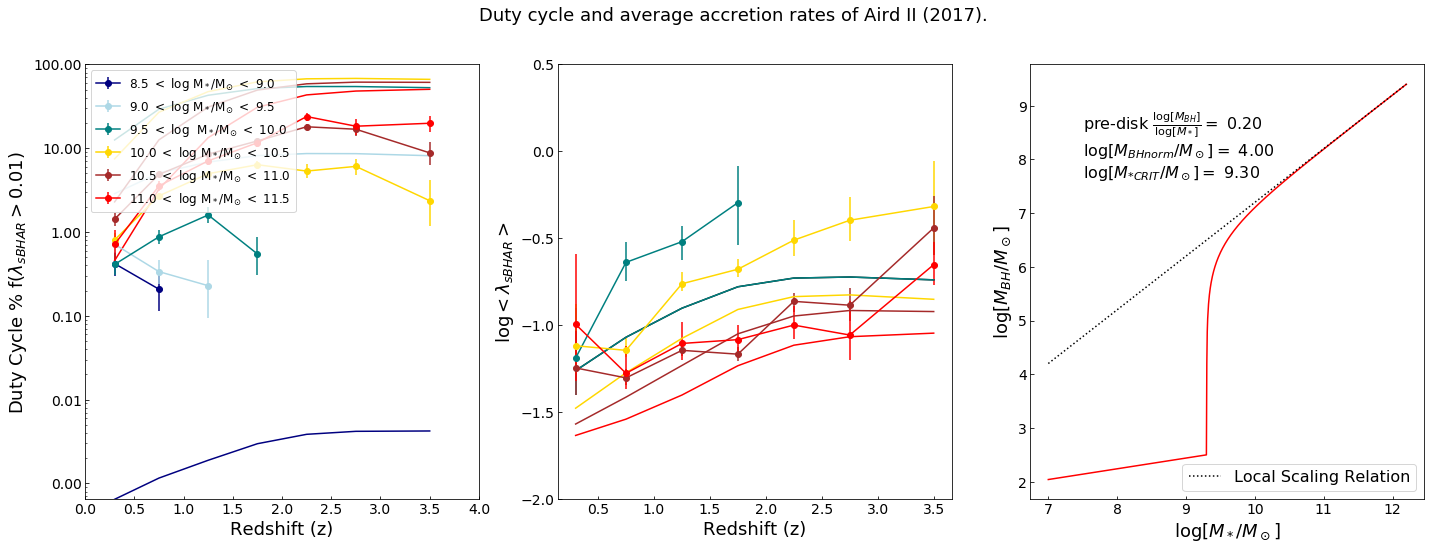

MovieWriter PillowWriter unavailable.


In [107]:
from matplotlib import pyplot as plt
from celluloid import Camera
import numpy as np

frames = 9
slopes, norms, crits = list(np.linspace(0.2,1.5,frames,endpoint=False)), list(np.linspace(4,1,frames,endpoint=False)), list(np.linspace(9.3,10.7,frames+frames/3,endpoint=False))
slopes.extend(np.linspace(1.5,1.0,frames/3)), norms.extend(np.linspace(1,0,frames/3))#, crits.extend(np.linspace(10.0,10.3,frames/3))


fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(24,8))
colors = ['navy', 'lightblue', 'teal', 'gold', 'brown', 'r']
labels = [r'8.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.0', r'9.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 9.5', r'9.5 $<$ $\log$  M$_*/$M$_{\odot}$ $<$ 10.0',\
          r'10.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 10.5', r'10.5 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.0', r'11.0 $<$ $\log$ M$_*/$M$_{\odot}$ $<$ 11.5']

ax1.set_xlabel('Redshift (z)',fontsize=18)
ax1.set_ylabel('Duty Cycle % f$(\lambda_{sBHAR} > 0.01)$',fontsize=18)

ax2.set_xlabel('Redshift (z)',fontsize=18)
ax2.set_ylabel('$\log<\lambda_{sBHAR}>$',fontsize=18)

ax3.set_xlabel('$\log[M_*/M_\odot]$',fontsize=18)
ax3.set_ylabel('$\log[M_{BH}/M_\odot]$',fontsize=18)

camera = Camera(fig)
leg_count = 0

for s, n, m in zip(slopes,norms,crits):
    info = r'pre-disk $\frac{\log[M_{BH}]}{\log[M_*]} =$ %.02f'%s
    info += '\n'+r'$\log[M_{BHnorm}/M_\odot] =$ %.02f'%n
    info += '\n'+r'$\log[M_{*CRIT}/M_\odot] =$ %.02f'%m
    
    fig.suptitle('Duty cycle and average accretion rates of Aird II (2017).',fontsize =18)
    plot_duty(s, n, m)
    if leg_count == 0:
        ax1.legend(fontsize = 12, loc='upper left')
        ax3.legend(loc='lower right',fontsize=16)
    leg_count += 1
    ax3.text(7.5,7.75,info,fontsize = 16)
    plt.pause(2)
    camera.snap()

animation = camera.animate()
animation.save('params_v_duty.gif', writer='PillowWriter', fps=2)